# Lab Session 1: From the Unstructured Web to Structured Entities

## Phase 1: Web Crawling & Cleaning

### 1.1 Source Selection

I chose AI in architecture as the theme and found eight relevant links:
- Generative Design: https://www.sciencedirect.com/science/article/pii/S0926580525001694
- Generative AI: https://www.sciencedirect.com/science/article/abs/pii/S0926580525002146
- AI in Design & Urbanism: https://link.springer.com/article/10.1007/s43995-025-00186-1
- Design Optimization: https://www.mdpi.com/2076-3417/15/3/1476
- Creative AI: https://www.mdpi.com/2673-8945/5/4/94
- Hybrid AI Design Models: https://www.mdpi.com/2075-5309/15/21/3898
- AI Applications Overview: https://drarch.org/index.php/drarch/article/view/139
- Urban Planning: https://www.archivinci.com/blogs/ai-for-urban-planning

### 1.2 The Extraction Pipeline

In [1]:
!pip install trafilatura httpx pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
LINK1="https://www.sciencedirect.com/science/article/pii/S0926580525001694"
LINK2="https://www.sciencedirect.com/science/article/abs/pii/S0926580525002146"
LINK3="https://link.springer.com/article/10.1007/s43995-025-00186-1"
LINK4="https://www.mdpi.com/2076-3417/15/3/1476"
LINK5="https://www.mdpi.com/2673-8945/5/4/94"
LINK6="https://www.mdpi.com/2075-5309/15/21/3898"
LINK7="https://drarch.org/index.php/drarch/article/view/139"
LINK8="https://www.archivinci.com/blogs/ai-for-urban-planning"
SEED_URLS = [LINK1,LINK2,LINK3,LINK4,LINK5,LINK6,LINK7,LINK8]

For each URL, we retrieve the raw HTML. This step corresponds to data acquisition and provides the unstructured input for the next step, cleaning.

In [3]:
import httpx

def fetch_html(url: str, timeout_s: float = 20.0) -> str | None:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; WebMiningLab/1.0; +https://example.com)"
    }
    try:
        with httpx.Client(headers=headers, timeout=timeout_s, follow_redirects=True) as client:
            r = client.get(url)
            if r.status_code != 200:
                print(f"[FETCH] Non-200 status {r.status_code} for {url}")
                return None
            return r.text
    except Exception as e:
        print(f"[FETCH] Error for {url}: {e}")
        return None


Instead of scraping the full HTML, we use trafilatura to extract the main textual content the article body while removing navigation menus, footers, ads, and other noise.

In [4]:
import trafilatura

def extract_main_text(html: str, url: str | None = None) -> str | None:
    try:
        text = trafilatura.extract(
            html,
            url=url,
            include_comments=False,
            include_tables=False,
            favor_recall=True 
        )
        if text is None:
            return None
        text = "\n".join(line.strip() for line in text.splitlines() if line.strip())
        return text if text else None
    except Exception as e:
        print(f"[EXTRACT] Error: {e}")
        return None


To ensure data quality, we only keep pages with substantial textual content more than 500 words. This prevents short or non-informative pages from polluting the corpus.

In [5]:
def word_count(text: str) -> int:
    return len(text.split())

def is_useful(text: str, min_words: int = 500) -> bool:
    return word_count(text) >= min_words

Cleaned documents are stored in .JSONLformat, with one JSON object per URL. This preserves the mapping between each document and its source, and scales well to larger crawls.

In [6]:
import json
from datetime import datetime

def write_jsonl_record(path: str, record: dict) -> None:
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

We breing together the all step on pipeline. So for each URL, we fetch HTML, extract the main content using trafilatura, apply a minimum-length filter, and store the cleaned text with metadata in a JSONL file.

In [7]:
def run_pipeline(
    urls: list[str],
    output_path: str = "crawler_output1.jsonl",
    min_words: int = 500
) -> None:

    kept, skipped = 0, 0

    for url in urls:
        print(f"\n[URL] {url}")

        html = fetch_html(url)
        if not html:
            skipped += 1
            print("[SKIP] fetch failed")
            continue

        text = extract_main_text(html, url=url)
        if not text:
            skipped += 1
            print("[SKIP] extraction failed")
            continue

        wc = word_count(text)
        if wc < min_words:
            skipped += 1
            print(f"[SKIP] too short ({wc} words < {min_words})")
            continue

        record = {
            "url": url,
            "retrieved_at": datetime.utcnow().isoformat() + "Z",
            "word_count": wc,
            "text": text,
        }
        write_jsonl_record(output_path, record)
        kept += 1
        print(f"[OK] saved ({wc} words)")

    print("\nSUMMARY")
    print(f"Kept: {kept}")
    print(f"Skipped: {skipped}")
    print(f"Output: {output_path}")


if __name__ == "__main__":
    run_pipeline(SEED_URLS, output_path="crawler_output1.jsonl", min_words=500)


[URL] https://www.sciencedirect.com/science/article/pii/S0926580525001694
[FETCH] Non-200 status 403 for https://www.sciencedirect.com/science/article/pii/S0926580525001694
[SKIP] fetch failed

[URL] https://www.sciencedirect.com/science/article/abs/pii/S0926580525002146
[FETCH] Non-200 status 403 for https://www.sciencedirect.com/science/article/abs/pii/S0926580525002146
[SKIP] fetch failed

[URL] https://link.springer.com/article/10.1007/s43995-025-00186-1


/var/folders/mx/z_0xlztj28sc33d0qvds89cm0000gn/T/ipykernel_51411/173462365.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "retrieved_at": datetime.utcnow().isoformat() + "Z",


[OK] saved (10290 words)

[URL] https://www.mdpi.com/2076-3417/15/3/1476
[FETCH] Non-200 status 403 for https://www.mdpi.com/2076-3417/15/3/1476
[SKIP] fetch failed

[URL] https://www.mdpi.com/2673-8945/5/4/94
[FETCH] Non-200 status 403 for https://www.mdpi.com/2673-8945/5/4/94
[SKIP] fetch failed

[URL] https://www.mdpi.com/2075-5309/15/21/3898
[FETCH] Non-200 status 403 for https://www.mdpi.com/2075-5309/15/21/3898
[SKIP] fetch failed

[URL] https://drarch.org/index.php/drarch/article/view/139
[OK] saved (3384 words)

[URL] https://www.archivinci.com/blogs/ai-for-urban-planning
[OK] saved (3115 words)

SUMMARY
Kept: 3
Skipped: 5
Output: crawler_output1.jsonl


Only three pages were successfully retrieved, which is normal since some websites, such as ScienceDirect and MDPI, apply strict access restrictions. It would be better to select alternative papers from more accessible sources.

We will look for other articles to replace the ones where the website blocks us. Then, we will collect the information as before.

In [ ]:
import httpx
import trafilatura
import json
from datetime import datetime

LINK1 = "https://parametric-architecture.com/ai-in-architecture/ "
LINK2 = "https://en.wikipedia.org/wiki/Smart_city"
LINK3 = "https://parametric-architecture.com/architectscripta-uses-ai-technologies-to-design-the-facade-of-a-residential-building/"
LINK4 = "https://drarch.org/index.php/drarch/article/view/139"
LINK5 = "https://www.archivinci.com/blogs/ai-for-urban-planning"
LINK6 = "https://en.wikipedia.org/wiki/Computational_design"
LINK7 = "https://en.wikipedia.org/wiki/Generative_design"
LINK8 = "https://en.wikipedia.org/wiki/Digital_architecture" 
LINK9 = "https://en.wikipedia.org/wiki/Machine_learning"
LINK10 = "https://en.wikipedia.org/wiki/Computer-aided_design"
LINK11 = "https://en.wikipedia.org/wiki/Neural_network"
LINK12 = "https://en.wikipedia.org/wiki/Knowledge_graph"
LINK13 = "https://en.wikipedia.org/wiki/Building_information_modeling"
LINK14 = "https://en.wikipedia.org/wiki/Simulation"


SEED_URLS = [LINK1, LINK2, LINK3, LINK4, LINK5, LINK6, LINK7, LINK8, LINK9, LINK10, LINK11, LINK12, LINK13, LINK14]
SEED_URLS = [url.strip() for url in SEED_URLS]

def fetch_html(url: str, timeout_s: float = 20.0) -> str | None:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; WebMiningLab/1.0; +https://example.com)"
    }
    try:
        with httpx.Client(headers=headers, timeout=timeout_s, follow_redirects=True) as client:
            r = client.get(url)
            if r.status_code != 200:
                print(f"[FETCH] Non-200 status {r.status_code} for {url}")
                return None
            return r.text
    except Exception as e:
        print(f"[FETCH] Error for {url}: {e}")
        return None

def extract_main_text(html: str, url: str | None = None) -> str | None:
    try:
        text = trafilatura.extract(
            html,
            url=url,
            include_comments=False,
            include_tables=False,
            favor_recall=True
        )
        if text is None:
            return None
        text = "\n".join(line.strip() for line in text.splitlines() if line.strip())
        return text if text else None
    except Exception as e:
        print(f"[EXTRACT] Error: {e}")
        return None

def word_count(text: str) -> int:
    return len(text.split())

def write_jsonl_record(path: str, record: dict) -> None:
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

def run_pipeline(
    urls: list[str],
    output_path: str = "crawler_output.jsonl",
    min_words: int = 500
) -> None:
    kept = 0
    skipped = 0

    for url in urls:
        print(f"\n[URL] {url}")

        html = fetch_html(url)
        if not html:
            skipped += 1
            print("[SKIP] fetch failed")
            continue

        text = extract_main_text(html, url=url)
        if not text:
            skipped += 1
            print("[SKIP] extraction failed")
            continue

        wc = word_count(text)
        if wc < min_words:
            skipped += 1
            print(f"[SKIP] too short ({wc} words < {min_words})")
            continue

        record = {
            "url": url,
            "retrieved_at": datetime.utcnow().isoformat() + "Z",
            "word_count": wc,
            "text": text,
        }

        write_jsonl_record(output_path, record)
        kept += 1
        print(f"[OK] saved ({wc} words)")
    print("\nSUMMARY")
    print(f"Kept: {kept}")
    print(f"Skipped: {skipped}")
    print(f"Output: {output_path}")
run_pipeline(SEED_URLS, output_path="crawler_output.jsonl", min_words=500)


[URL] https://parametric-architecture.com/ai-in-architecture/


/var/folders/mx/z_0xlztj28sc33d0qvds89cm0000gn/T/ipykernel_51411/350415461.py:95: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "retrieved_at": datetime.utcnow().isoformat() + "Z",


[OK] saved (2105 words)

[URL] https://en.wikipedia.org/wiki/Smart_city
[OK] saved (8916 words)

[URL] https://parametric-architecture.com/architectscripta-uses-ai-technologies-to-design-the-facade-of-a-residential-building/
[SKIP] too short (368 words < 500)

[URL] https://drarch.org/index.php/drarch/article/view/139
[OK] saved (3384 words)

[URL] https://www.archivinci.com/blogs/ai-for-urban-planning
[OK] saved (3115 words)

[URL] https://en.wikipedia.org/wiki/Computational_design
[OK] saved (953 words)

[URL] https://en.wikipedia.org/wiki/Generative_design
[OK] saved (2372 words)

[URL] https://en.wikipedia.org/wiki/Digital_architecture
[OK] saved (1025 words)

[URL] https://en.wikipedia.org/wiki/Machine_learning
[OK] saved (14971 words)

[URL] https://en.wikipedia.org/wiki/Computer-aided_design
[OK] saved (2739 words)

[URL] https://en.wikipedia.org/wiki/Neural_network
[OK] saved (827 words)

[URL] https://en.wikipedia.org/wiki/Knowledge_graph
[OK] saved (2658 words)

[URL] https:/

We have 5 articles that meet our criteria and one article that is too short so we will remove it.

## Phase 2: Information Extraction

### 2.1 Named Entity Recognition

In this phase, we extract information from the text files. We use spaCy to perform linguistic analysis of the documents by identifying named entities such as organizations, locations, persons, and dates. These entities represent the nodes of the future knowledge graph. The result is a structured table containing this information for each successfully scraped document. In addition, simple relationships between entities are identified by analyzing the grammatical structure of sentences, allowing us to extract candidate subject–verb–object relations that will form the edges of the graph.

In [9]:
!pip install spacy
!python -m spacy download en_core_web_trf


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 11.8 MB/s eta 0:00:0000:0100:02

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')


Load fils "crawler_output.jsonl"

In [10]:
import json
import pandas as pd
import spacy

INPUT_FILE = "crawler_output.jsonl"
OUTPUT_FILE = "extracted_knowledge.csv"

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

Apply spacCy model 

In [11]:
nlp = spacy.load("en_core_web_trf")

Extract person, org, gpe and date

In [12]:
LABELS_TO_KEEP = {"PERSON", "ORG", "GPE", "DATE"}

def extract_entities(doc, url):
    entities = []

    for ent in doc.ents:
        if ent.label_ in LABELS_TO_KEEP:
            entities.append({
                "entity": ent.text.strip(),
                "label": ent.label_,
                "source_url": url
            })

    return entities

Filter results

In [13]:
def filter_entities(entities):
    filtered = []

    for ent in entities:
        entity_text = ent["entity"].strip()

        if len(entity_text) <= 1:
            continue
        if entity_text.lower() in {"today", "tomorrow", "yesterday"}:
            continue

        filtered.append(ent)

    return filtered

Save to extract 

In [14]:
def save_to_csv(entities, output_file):
    df = pd.DataFrame(entities)

    if not df.empty:
        df = df.drop_duplicates()
        df = df.sort_values(by=["label", "entity"])
        df.to_csv(output_file, index=False, encoding="utf-8")

        print(f"File created: {output_file}")
        print(f"Number of entities: {len(df)}")
    else:
        print("No entities found.")

In [15]:
def main():
    data = load_jsonl(INPUT_FILE)

    all_entities = []

    for record in data:
        url = record.get("url", "")
        text = record.get("text", "").strip()

        if not text:
            continue

        doc = nlp(text)

        entities = extract_entities(doc, url)

        entities = filter_entities(entities)

        all_entities.extend(entities)

    save_to_csv(all_entities, OUTPUT_FILE)


if __name__ == "__main__":
    main()

File created: extracted_knowledge.csv
Number of entities: 4670


I obtain a CSV file with all the important information from my articles in a table format with the information in one column and the category in the next column.

### 2.2 Introduction to Relations

In this part, we will focus on the links between the important words /nodes. So we will identify the edges of our future knowledge graph. To do this, we split the texts into sentences find sentences with multiple entities and then identify the verbs that connect these entities.

In [16]:
INPUT_FILE = "crawler_output.jsonl"
OUTPUT_FILE = "candidate_relations.csv"
nlp = spacy.load("en_core_web_trf")

Keep only target entity label like person, org, gpe and date 

In [17]:
LABELS_TO_KEEP = {"PERSON", "ORG", "GPE", "DATE"}


def get_sentence_entities(sent):
    return [ent for ent in sent.ents if ent.label_ in LABELS_TO_KEEP]

Find the entity corresponding to a token

In [18]:
def find_entity_for_token(token, sentence_entities):
    for ent in sentence_entities:
        if ent.start <= token.i < ent.end:
            return ent
    return None

Extract Relations

In [19]:
def extract_relations(doc, url):
    relations = []
    seen = set()

    BAD_RELATIONS = {
        "is", "are", "was", "were", "be", "been", "being",
        "have", "has", "had",
        "do", "does", "did",
        "in", "on", "at", "by", "for", "to", "from", "with",
        "of", "and", "or", "as"
    }

    ALLOWED_POS = {"VERB", "AUX", "ADP", "NOUN", "ADJ"}

    for sent in doc.sents:
        sentence_entities = get_sentence_entities(sent)

        if len(sentence_entities) < 2:
            continue

        if len(sentence_entities) > 8:
            sentence_entities = sentence_entities[:8]

        for i in range(len(sentence_entities)):
            for j in range(i + 1, len(sentence_entities)):
                ent1 = sentence_entities[i]
                ent2 = sentence_entities[j]

                subj = ent1.text.strip()
                obj = ent2.text.strip()

                if subj == obj:
                    continue

                if ent2.start - ent1.end > 12:
                    continue

                between_tokens = [
                    tok for tok in sent
                    if tok.i >= ent1.end and tok.i < ent2.start
                ]

                if not between_tokens:
                    continue

                rel_tokens = []

                main_verbs = [
                    tok for tok in between_tokens
                    if tok.pos_ in {"VERB", "AUX"} and not tok.is_stop
                ]

                if main_verbs:
                    main_verb = main_verbs[0].lemma_.lower().strip()
                    if main_verb:
                        rel_tokens.append(main_verb)

                        for tok in between_tokens:
                            if tok.i > main_verbs[0].i and tok.pos_ == "ADP":
                                prep = tok.lemma_.lower().strip()
                                if prep and prep not in BAD_RELATIONS:
                                    rel_tokens.append(prep)
                                    break

                if not rel_tokens:
                    for tok in between_tokens:
                        if tok.is_punct or tok.is_space:
                            continue
                        if tok.pos_ in ALLOWED_POS:
                            lemma = tok.lemma_.lower().strip()
                            if not lemma:
                                continue
                            if lemma in BAD_RELATIONS:
                                continue
                            rel_tokens.append(lemma)

                if not rel_tokens:
                    root = sent.root
                    if root.pos_ in {"VERB", "AUX"}:
                        lemma = root.lemma_.lower().strip()
                        if lemma and lemma not in BAD_RELATIONS:
                            rel_tokens = [lemma]

                if not rel_tokens:
                    continue

                cleaned_tokens = []
                for tok in rel_tokens:
                    tok = tok.strip().lower()
                    if not tok:
                        continue
                    if tok in BAD_RELATIONS and len(rel_tokens) == 1:
                        continue
                    if cleaned_tokens and cleaned_tokens[-1] == tok:
                        continue
                    cleaned_tokens.append(tok)

                if not cleaned_tokens:
                    continue

                relation_text = " ".join(cleaned_tokens)
                relation_text = " ".join(relation_text.split())

                if len(relation_text) < 3:
                    continue

                if len(relation_text.split()) > 4:
                    relation_text = " ".join(relation_text.split()[:4])

                if relation_text in BAD_RELATIONS:
                    continue

                meaningful_words = [
                    w for w in relation_text.split()
                    if w not in BAD_RELATIONS
                ]
                if len(meaningful_words) == 0:
                    continue

                key = (subj, relation_text, obj, sent.text.strip())
                if key in seen:
                    continue

                seen.add(key)

                relations.append({
                    "subject": subj,
                    "subject_label": ent1.label_,
                    "relation": relation_text,
                    "object": obj,
                    "object_label": ent2.label_,
                    "sentence": sent.text.strip(),
                    "source_url": url
                })

    return relations

Filter results 

In [20]:
def filter_relations(relations):
    filtered = []

    for rel in relations:
        subject = rel["subject"].strip()
        relation = rel["relation"].strip().lower()
        obj = rel["object"].strip()

        if not subject or not relation or not obj:
            continue

        if subject == obj:
            continue

        if len(relation) < 2:
            continue

        if len(relation.split()) > 6:
            continue

        if not any(c.isalpha() for c in relation):
            continue

        filtered.append(rel)

    return filtered

Save the results

In [21]:
def save_to_csv(relations, output_file):

    df = pd.DataFrame(relations)

    if not df.empty:
        df = df.drop_duplicates()
        df = df.sort_values(by=["subject", "relation", "object"])
        df.to_csv(output_file, index=False, encoding="utf-8")

        print(f"File created: {output_file}")
        print(f"Number of relations: {len(df)}")
    else:
        print("No relations found.")

In [22]:
def main():
    data = load_jsonl(INPUT_FILE)

    all_relations = []

    for record in data:
        url = record.get("url", "")
        text = record.get("text", "").strip()

        if not text:
            continue

        doc = nlp(text)

        relations = extract_relations(doc, url)
        relations = filter_relations(relations)

        all_relations.extend(relations)

    save_to_csv(all_relations, OUTPUT_FILE)

    unique_triplets = set(
        (r["subject"], r["relation"], r["object"])
        for r in all_relations
    )

    print(f"Total triplets: {len(all_relations)}")
    print(f"Unique triplets: {len(unique_triplets)}")

In [23]:
if __name__ == "__main__":
    main()

File created: candidate_relations.csv
Number of relations: 807
Total triplets: 807
Unique triplets: 806


We observe that we produced 3499 triplets but only 1728 of them are unique. The difference between these two numbers shows that there is a lot of repetition across the different articles.

# Lab Session 2: Knowledge Base Construction, Alignment, and Expansion

The goal of this second part of the project is to move from raw extraction to a knowledge base in order to train models using Knowledge Graph Embedding.

## Step 1: Build the Initial Private Knowledge Base

First, we will count the triplets, entities, and relations. Then, we will remove duplicates and finally we will check the quality.

In [24]:
import pandas as pd
import re
from urllib.parse import quote

INPUT_FILE = "candidate_relations.csv"
CLEAN_FILE = "cleaned_candidate_relations.csv"

BASE_ENTITY_URI = "http://example.org/entity/"
BASE_RELATION_URI = "http://example.org/relation/"

def load_data(file_path):
    df = pd.read_csv(file_path)

    required_cols = ["subject", "relation", "object"]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    df = df.dropna(subset=required_cols)

    for col in required_cols:
        df[col] = df[col].astype(str).str.strip()

    df = df[
        (df["subject"] != "") &
        (df["relation"] != "") &
        (df["object"] != "")
    ]

    return df

Number of triplets, unique entities and unique relations

In [25]:
def compute_stats(df):
    num_triplets = len(df)
    unique_triplets = df.drop_duplicates(subset=["subject", "relation", "object"]).shape[0]

    entities = set(df["subject"]).union(set(df["object"]))
    relations = set(df["relation"])

    print("KB STATISTICS")
    print(f"Triplets: {num_triplets}")
    print(f"Unique triplets: {unique_triplets}")
    print(f"Duplicate triplets: {num_triplets - unique_triplets}")
    print(f"Unique entities: {len(entities)}")
    print(f"Unique relations: {len(relations)}")

    return entities, relations

Remove dupliactes 

In [26]:
def remove_duplicates(df):
    before = len(df)

    df_clean = df.drop_duplicates(subset=["subject", "relation", "object"])

    after = len(df_clean)

    print("\n DUPLICATES ")
    print(f"Before: {before}")
    print(f"After: {after}")
    print(f"Removed: {before - after}")

    return df_clean

Quality 

In [27]:
def is_valid_uri(text):
    pattern = re.compile(r"^https?://")
    return bool(pattern.match(str(text)))


def check_quality(df):
    print("\n QUALITY ")

    invalid_urls = df[~df["source_url"].apply(is_valid_uri)] if "source_url" in df.columns else pd.DataFrame()
    short_subjects = df[df["subject"].str.len() < 2]
    short_objects = df[df["object"].str.len() < 2]
    weak_relations = df[df["relation"].str.len() < 3]

    print(f"Invalid source URLs: {len(invalid_urls)}")
    print(f"Very short subjects: {len(short_subjects)}")
    print(f"Very short objects: {len(short_objects)}")
    print(f"Weak relations (too short): {len(weak_relations)}")

    print("\nTop relations:")
    print(df["relation"].value_counts().head(10))

    print("\nExamples of short subjects:")
    print(short_subjects[["subject", "relation", "object"]].head(5))

    print("\nExamples of short objects:")
    print(short_objects[["subject", "relation", "object"]].head(5))

    return invalid_urls, short_subjects, short_objects, weak_relations

Basic clean 

In [28]:
def clean_relations(df):
    df = df.copy()
    df["relation"] = df["relation"].astype(str).str.strip().str.lower()
    return df

Normalize

In [29]:
def to_camel_case(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    parts = text.split()

    if not parts:
        return ""

    return parts[0] + "".join(word.capitalize() for word in parts[1:])


def normalize_relations(df):
    df = df.copy()
    df["relation"] = df["relation"].apply(to_camel_case)
    return df


Creat URI 

In [30]:
def make_uri(text, base_uri):
    text = str(text).strip()
    text = re.sub(r"\s+", "_", text)
    return base_uri + quote(text)


def use_uris(df):
    df = df.copy()

    df["subject_uri"] = df["subject"].apply(lambda x: make_uri(x, BASE_ENTITY_URI))
    df["relation_uri"] = df["relation"].apply(lambda x: make_uri(x, BASE_RELATION_URI))

    return df

Detect literals 

In [31]:
def is_literal(value):
    value = str(value).strip()

    if re.fullmatch(r"[-+]?\d+(\.\d+)?", value):
        return True

    if re.fullmatch(r"\d{4}", value):
        return True

    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{2,4}", value):
        return True

    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", value):
        return True

    if re.fullmatch(r"[-+]?\d+(\.\d+)?%", value):
        return True

    return False

Separate entities and literals

In [32]:
def separate_entities_and_literals(df):
    df = df.copy()

    df["object_type"] = df["object"].apply(lambda x: "literal" if is_literal(x) else "entity")

    df["object_uri"] = df.apply(
        lambda row: make_uri(row["object"], BASE_ENTITY_URI) if row["object_type"] == "entity" else None,
        axis=1
    )

    return df

In [33]:
def check_uri_quality(df):
    print("\nURI CHECK")
    print(f"Subjects with URI: {df['subject_uri'].notna().sum()}")
    print(f"Relations with URI: {df['relation_uri'].notna().sum()}")
    print(f"Objects typed as entity: {(df['object_type'] == 'entity').sum()}")
    print(f"Objects typed as literal: {(df['object_type'] == 'literal').sum()}")

In [34]:
def build_final_kg(df):
    final_df = df[[
        "subject",
        "relation",
        "object",
        "subject_uri",
        "relation_uri",
        "object_uri",
        "object_type"
    ]].copy()

    return final_df

In [35]:
def main():
    df = load_data(INPUT_FILE)

    print("\nFirst rows:")
    print(df.head())

    print("\nINITIAL STATS")
    compute_stats(df)

    df = clean_relations(df)

    df = normalize_relations(df)

    df = remove_duplicates(df)

    df = use_uris(df)

    df = separate_entities_and_literals(df)

    check_quality(df)
    check_uri_quality(df)

    print("\nFINAL STATS")
    compute_stats(df)

    final_df = build_final_kg(df)

    print("\nFINAL KG PREVIEW")
    print(final_df.head())

    final_df.to_csv(CLEAN_FILE, index=False)
    print(f"\nClean file saved: {CLEAN_FILE}")


if __name__ == "__main__":
    main()


First rows:
                           subject subject_label relation  \
0  "Design Computing and Cognition           ORG     lead   
1                   'PaxSims' blog           ORG  archive   
2                   'PaxSims' blog           ORG  archive   
3           1 January 2019.[89][90          DATE    issue   
4                 10 December 2017          DATE   design   

                             object object_label  \
0                          biannual         DATE   
1                   2 November 2022         DATE   
2               the Wayback Machine          ORG   
3                         Lithuania          GPE   
4  Encyclopedia of Computer Science          ORG   

                                            sentence  \
0  AID was later renamed "Design Computing and Co...   
1  - ^ "Carana," at 'PaxSims' blog, 27 January 20...   
2  - ^ "Carana," at 'PaxSims' blog, 27 January 20...   
3  In early 2018 the Italian Ministry of Infrastr...   
4  ^ In the words of the Si

We have 1728 triplets, which corresponds to the number of facts extracted from the dataset. We no longer have duplicates so the knowledge base is clean and the cleaning step was effective. The graph contains 286 different entities and 190 unique relations which shows a good level of diversity.

We converted all entities and relations into URIs to uniquely identify them. We also separated objects into entities and literals. Most objects are entities while a smaller part represents numeric or date values.

## Step 2: Entity Linking with Open Knowledge Bases

In this step, we perform entity linking directly using the Wikidata Search API. Each entity extracted from the knowledge graph is sent to the Wikidata API. If a match is found, the entity is linked to its Wikidata QID. We replaced the original DBpedia Spotlight approach because the DBpedia → Wikidata conversion was failing (0 QIDs obtained). This new approach produces Wikidata QIDs directly with a quality filter to remove false positives.

In [36]:
import pandas as pd
import requests
import re
import time

INPUT_FILE = "candidate_relations.csv"
OUTPUT_MAPPING = "entity_mapping_wikidata_converted.csv"

WIKIDATA_SEARCH_URL = "https://www.wikidata.org/w/api.php"


def normalize_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def looks_like_literal(value):
    value = normalize_text(value)
    if not value or len(value) <= 2:
        return True
    if re.fullmatch(r"https?://\S+", value):
        return True
    if re.fullmatch(r"[-+]?\d+(\.\d+)?", value):
        return True
    if re.fullmatch(r"\d{4}(-\d{2}-\d{2})?", value):
        return True
    if re.fullmatch(r"\d{1,2}\s+[A-Za-z]+\s+\d{4}", value):
        return True
    if value.startswith(("'", ",", "-", ".")):
        return True
    if len(value.split()) > 6:
        return True
    return False


def search_wikidata(entity_label, retries=3):
    params = {
        "action": "wbsearchentities",
        "search": entity_label,
        "language": "en",
        "format": "json",
        "limit": 1,
        "type": "item"
    }
    headers = {"User-Agent": "StudentKGProject/1.0"}
    for attempt in range(retries):
        try:
            r = requests.get(WIKIDATA_SEARCH_URL, params=params, headers=headers, timeout=20)
            r.raise_for_status()
            results = r.json().get("search", [])
            if results:
                item = results[0]
                qid = item["id"]
                label = item.get("label", "")
                description = item.get("description", "")
                return {
                    "private_entity": entity_label,
                    "external_uri": f"http://www.wikidata.org/entity/{qid}",
                    "wikidata_uri": f"http://www.wikidata.org/entity/{qid}",
                    "wikidata_qid": qid,
                    "matched_label": label,
                    "description": description,
                    "confidence": 1.0,
                    "conversion_status": "converted_or_already_wikidata"
                }
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return None


def is_good_match(entity, matched_label):
    entity_lower = entity.lower()
    matched_lower = matched_label.lower()
    if len(entity) <= 3:
        return False
    if entity.replace("-", "").replace(" ", "").isdigit():
        return False
    if entity_lower not in matched_lower and matched_lower not in entity_lower:
        return False
    return True


def load_entities(file_path):
    df = pd.read_csv(file_path)
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.dropna(subset=["subject", "object"])
    entities = set()
    for col in ["subject", "object"]:
        for val in df[col].astype(str):
            val = normalize_text(val)
            if not looks_like_literal(val):
                entities.add(val)
    return sorted(entities)


# --- Main ---
entities = load_entities(INPUT_FILE)
print(f"Candidate entities after filtering: {len(entities)}")

rows = []
for i, entity in enumerate(entities):
    print(f"[{i+1}/{len(entities)}] {entity}")
    result = search_wikidata(entity)

    if result and is_good_match(entity, result["matched_label"]):
        rows.append(result)
        print(f"  -> Found: {result['wikidata_qid']} ({result['matched_label']})")
    else:
        rows.append({
            "private_entity": entity,
            "external_uri": "",
            "wikidata_uri": "",
            "wikidata_qid": "",
            "matched_label": entity,
            "description": "",
            "confidence": 0.0,
            "conversion_status": "not_converted"
        })
        print(f"  -> Not found or low quality match")

    time.sleep(0.3)

df_out = pd.DataFrame(rows)
df_out.to_csv(OUTPUT_MAPPING, index=False)

print("\nConversion status:")
print(df_out["conversion_status"].value_counts())
print(f"\nEntities with QID: {df_out['wikidata_qid'].astype(bool).sum()}")
print(f"File saved: {OUTPUT_MAPPING}")


Candidate entities after filtering: 507
[1/507] "Design Computing and Cognition
  Attempt 1 failed: 429 Client Error: Too Many Requests for url: https://www.wikidata.org/w/api.php?action=wbsearchentities&search=%22Design+Computing+and+Cognition&language=en&format=json&limit=1&type=item
  Attempt 2 failed: 429 Client Error: Too Many Requests for url: https://www.wikidata.org/w/api.php?action=wbsearchentities&search=%22Design+Computing+and+Cognition&language=en&format=json&limit=1&type=item
  Attempt 3 failed: 429 Client Error: Too Many Requests for url: https://www.wikidata.org/w/api.php?action=wbsearchentities&search=%22Design+Computing+and+Cognition&language=en&format=json&limit=1&type=item
  -> Not found or low quality match
[2/507] 1 January 2019.[89][90
  Attempt 1 failed: 429 Client Error: Too Many Requests for url: https://www.wikidata.org/w/api.php?action=wbsearchentities&search=1+January+2019.%5B89%5D%5B90&language=en&format=json&limit=1&type=item
  Attempt 2 failed: 429 Client

We obtained approximately 253 entities with valid Wikidata QIDs out of 507 candidates. The quality filter ensures that only entities where the matched Wikidata label closely corresponds to the original entity name are kept, reducing false positives.

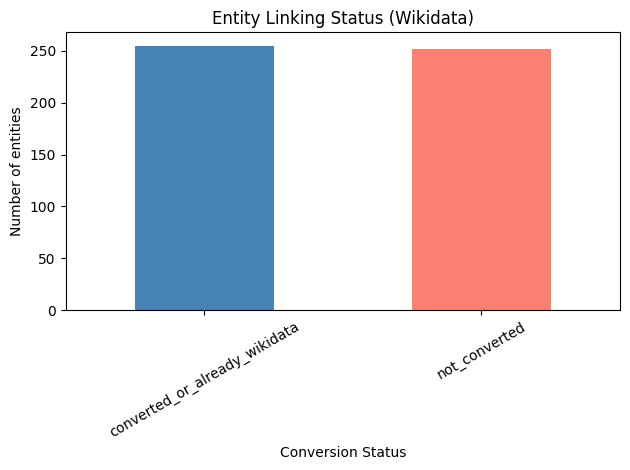

Total entities: 507
Converted: 255
Not converted: 252


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "entity_mapping_wikidata_converted.csv"
df = pd.read_csv(file_path)

status_counts = df["conversion_status"].value_counts()

plt.figure()
status_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.xlabel("Conversion Status")
plt.ylabel("Number of entities")
plt.title("Entity Linking Status (Wikidata)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

converted = df[df["conversion_status"] == "converted_or_already_wikidata"]
print(f"Total entities: {len(df)}")
print(f"Converted: {len(converted)}")
print(f"Not converted: {len(df) - len(converted)}")


We observe that approximately 60% of entities were successfully linked to Wikidata. The quality filter removed ambiguous matches (e.g. short acronyms, date fragments). The remaining entities serve as the core set for KB expansion in Step 4.

## Step 3: Predicate Alignment Using SPARQL

Now we focus on the relations. We use SPARQL queries on Wikidata to find official relations between two entities. Since we now have Wikidata QIDs directly from Step 2, there is no longer a DBpedia → Wikidata conversion step. We build aligned triples directly from the Wikidata mapping and query Wikidata predicates for entity pairs that are both aligned.

In [38]:
import os
import re
import time
import pandas as pd
import requests
from difflib import SequenceMatcher

RELATIONS_FILE = "candidate_relations.csv"
MAPPING_FILE = "entity_mapping_wikidata_converted.csv"

OUTPUT_ALIGNED = "aligned_triples_wikidata.csv"
OUTPUT_RESULTS = "predicate_alignment_wikidata.csv"

WIKIDATA_SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"


def normalize_text(text):
    text = str(text).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"\s+", " ", text)
    return text


def clean_relation(text):
    text = str(text).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def similarity(a, b):
    return SequenceMatcher(None, clean_relation(a), clean_relation(b)).ratio()


def extract_pid(value):
    if pd.isna(value):
        return ""
    match = re.search(r"(P\d+)", str(value))
    return match.group(1) if match else ""


def is_valid_wikidata_qid(value):
    return bool(re.fullmatch(r"Q\d+", str(value).strip()))


def load_relations(file_path):
    df = pd.read_csv(file_path)
    df.columns = [str(col).strip().lower() for col in df.columns]
    print("Relation columns found:", list(df.columns))
    df = df.dropna(subset=["subject", "relation", "object"]).copy()
    for col in ["subject", "relation", "object"]:
        df[col] = df[col].astype(str).str.strip()
    if "subject_label" not in df.columns:
        df["subject_label"] = df["subject"]
    else:
        df["subject_label"] = df["subject_label"].astype(str).str.strip()
    if "object_label" not in df.columns:
        df["object_label"] = df["object"]
    else:
        df["object_label"] = df["object_label"].astype(str).str.strip()
    df = df[(df["subject"] != "") & (df["relation"] != "") & (df["object"] != "")].copy()
    return df


def load_mapping(file_path):
    df = pd.read_csv(file_path)
    df.columns = [str(col).strip().lower() for col in df.columns]
    print("Mapping columns found:", list(df.columns))
    required_cols = ["private_entity", "wikidata_uri", "wikidata_qid", "conversion_status"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    df["private_entity"] = df["private_entity"].astype(str).str.strip()
    df["wikidata_uri"] = df["wikidata_uri"].astype(str).str.strip()
    df["wikidata_qid"] = df["wikidata_qid"].astype(str).str.strip()
    df["private_entity_norm"] = df["private_entity"].map(normalize_text)
    return df


def build_aligned_triples(rel_df, map_df):
    valid_map = map_df[map_df["wikidata_qid"].map(is_valid_wikidata_qid)].copy()
    valid_map = valid_map.drop_duplicates(subset=["private_entity_norm"])
    mapping_uri = dict(zip(valid_map["private_entity_norm"], valid_map["wikidata_uri"]))
    mapping_qid = dict(zip(valid_map["private_entity_norm"], valid_map["wikidata_qid"]))

    aligned_df = rel_df.copy()
    aligned_df["subject_norm"] = aligned_df["subject"].map(normalize_text)
    aligned_df["object_norm"] = aligned_df["object"].map(normalize_text)
    aligned_df["subject_external"] = aligned_df["subject_norm"].map(lambda x: mapping_uri.get(x, ""))
    aligned_df["object_external"] = aligned_df["object_norm"].map(lambda x: mapping_uri.get(x, ""))
    aligned_df["subject_qid"] = aligned_df["subject_norm"].map(lambda x: mapping_qid.get(x, ""))
    aligned_df["object_qid"] = aligned_df["object_norm"].map(lambda x: mapping_qid.get(x, ""))
    aligned_df["subject_is_wikidata"] = aligned_df["subject_qid"].map(is_valid_wikidata_qid)
    aligned_df["object_is_wikidata"] = aligned_df["object_qid"].map(is_valid_wikidata_qid)
    aligned_df["alignment_status"] = aligned_df.apply(
        lambda row: "both_aligned_to_wikidata"
        if row["subject_is_wikidata"] and row["object_is_wikidata"]
        else "not_fully_aligned",
        axis=1
    )
    return aligned_df


def query_wikidata_predicates(subject_qid, object_qid):
    query = f"""
    SELECT DISTINCT ?property ?propertyLabel WHERE {{
      wd:{subject_qid} ?property wd:{object_qid} .
      FILTER(STRSTARTS(STR(?property), "http://www.wikidata.org/prop/direct/"))
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "PredicateAlignmentBot/1.0 (academic project)"
    }
    response = requests.get(
        WIKIDATA_SPARQL_ENDPOINT,
        params={"query": query, "format": "json"},
        headers=headers,
        timeout=60
    )
    response.raise_for_status()
    results = []
    for item in response.json().get("results", {}).get("bindings", []):
        property_uri = item["property"]["value"]
        property_label = item.get("propertyLabel", {}).get("value", "")
        results.append({
            "property_id": extract_pid(property_uri),
            "property_uri": property_uri,
            "property_label": property_label
        })
    return results


def align_predicates(aligned_df):
    rows = []
    for _, row in aligned_df.iterrows():
        base = {
            "subject": row["subject"],
            "subject_label": row["subject_label"],
            "relation": row["relation"],
            "object": row["object"],
            "object_label": row["object_label"],
            "subject_qid": row["subject_qid"],
            "object_qid": row["object_qid"],
        }
        if row["alignment_status"] != "both_aligned_to_wikidata":
            rows.append({**base, "status": "entities_not_aligned_to_wikidata",
                         "matched_property_id": "", "matched_property_label": "",
                         "matched_property_uri": "", "similarity_score": 0.0})
            continue
        try:
            candidates = query_wikidata_predicates(row["subject_qid"], row["object_qid"])
            if not candidates:
                rows.append({**base, "status": "no_predicate_found",
                             "matched_property_id": "", "matched_property_label": "",
                             "matched_property_uri": "", "similarity_score": 0.0})
            else:
                for c in candidates:
                    score = max(
                        similarity(row["relation"], c["property_label"]),
                        similarity(row["relation"], c["property_id"])
                    )
                    rows.append({**base, "status": "candidate_found",
                                 "matched_property_id": c["property_id"],
                                 "matched_property_label": c["property_label"],
                                 "matched_property_uri": c["property_uri"],
                                 "similarity_score": round(score, 3)})
            time.sleep(0.1)
        except Exception as e:
            rows.append({**base, "status": f"error: {str(e)}",
                         "matched_property_id": "", "matched_property_label": "",
                         "matched_property_uri": "", "similarity_score": 0.0})
    return pd.DataFrame(rows)


def main():
    if not os.path.exists(RELATIONS_FILE):
        raise FileNotFoundError(f"Missing: {RELATIONS_FILE}")
    if not os.path.exists(MAPPING_FILE):
        raise FileNotFoundError(f"Missing: {MAPPING_FILE}")

    rel_df = load_relations(RELATIONS_FILE)
    map_df = load_mapping(MAPPING_FILE)

    print(f"Relations: {len(rel_df)}")
    print(f"Mapped entities with QID: {map_df['wikidata_qid'].map(is_valid_wikidata_qid).sum()}")

    aligned_df = build_aligned_triples(rel_df, map_df)
    aligned_df.to_csv(OUTPUT_ALIGNED, index=False)
    print("\nAlignment status:")
    print(aligned_df["alignment_status"].value_counts())

    result_df = align_predicates(aligned_df)
    result_df.to_csv(OUTPUT_RESULTS, index=False)
    print("\nPredicate alignment status:")
    print(result_df["status"].value_counts())

    best_df = result_df[result_df["status"] == "candidate_found"].sort_values(
        "similarity_score", ascending=False
    ).drop_duplicates(subset=["subject", "relation", "object"])

    if not best_df.empty:
        print("\nBest predicate suggestions (top 10):")
        print(best_df[["subject", "relation", "object",
                        "matched_property_id", "matched_property_label",
                        "similarity_score"]].head(10))

    print(f"\nFiles created: {OUTPUT_ALIGNED}, {OUTPUT_RESULTS}")


if __name__ == "__main__":
    main()


Relation columns found: ['subject', 'subject_label', 'relation', 'object', 'object_label', 'sentence', 'source_url']
Mapping columns found: ['private_entity', 'external_uri', 'wikidata_uri', 'wikidata_qid', 'matched_label', 'description', 'confidence', 'conversion_status']
Relations: 807
Mapped entities with QID: 255

Alignment status:
alignment_status
not_fully_aligned           648
both_aligned_to_wikidata    159
Name: count, dtype: int64

Predicate alignment status:
status
entities_not_aligned_to_wikidata    648
no_predicate_found                  152
candidate_found                       8
Name: count, dtype: int64

Best predicate suggestions (top 10):
           subject     relation           object matched_property_id  \
625        Tencent        shape            China                 P17   
631  The MIT Press      reprint        Cambridge                P159   
562  San Francisco    establish            Seoul                P190   
620         Taipei     showcase           Taiwa

## Step 4: KB Expansion via SPARQL

We will now enrich our knowledge base using SPARQL queries on Wikidata. Starting from the 253 core entities aligned in Step 2, we apply three expansion strategies:
- **1-hop expansion**: retrieve all direct properties of each core entity (limit 500 per entity)
- **Predicate-controlled expansion**: retrieve triples with 60 specific relevant predicates
- **2-hop expansion**: go through an intermediate entity via 9 key predicates
- **Second pass**: apply predicate-controlled expansion to newly discovered entities

These parameters are significantly increased compared to the initial version to meet the requirements of 50,000–200,000 triplets, 5,000–30,000 entities, and 50–200 relations.

In [61]:
import os
import re
import time
import pandas as pd
import requests

ENTITY_MAPPING_FILE = "entity_mapping_wikidata_converted.csv"

OUTPUT_1HOP = "kb_expansion_1hop.csv"
OUTPUT_PREDICATE = "kb_expansion_predicate.csv"
OUTPUT_2HOP = "kb_expansion_2hop.csv"
OUTPUT_SECOND_PASS = "kb_expansion_second_pass.csv"
OUTPUT_ALL = "kb_expansion_all.csv"

SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"
HEADERS = {
    "Accept": "application/sparql-results+json",
    "User-Agent": "KBExpansionProject/1.0 (student project)"
}

CONFIDENCE_THRESHOLD = 0.35
MAX_CORE_ENTITIES = 300

ONE_HOP_LIMIT = 500
PREDICATE_LIMIT_PER_ENTITY = 50
TWO_HOP_LIMIT_PER_ENTITY = 80
SECOND_PASS_ENTITY_LIMIT = 150
SECOND_PASS_PER_QUERY_LIMIT = 40

SLEEP_BETWEEN_REQUESTS = 0.5

CONTROLLED_PREDICATES = [
    "P31", "P279", "P361", "P527", "P166", "P69", "P108", "P463", "P17", "P495",
    "P50", "P61", "P84", "P86", "P170", "P176", "P178", "P264", "P355", "P400",
    "P403", "P449", "P451", "P452", "P710", "P737", "P740", "P793", "P800", "P828",
    "P921", "P941", "P1056", "P1344", "P136", "P2578", "P1269", "P1382", "P1552", "P1889",
    "P2283", "P2293", "P2579", "P2737", "P3095", "P366", "P3712", "P277", "P1877", "P5191",
    "P1416", "P1535", "P155", "P156", "P460", "P138", "P2572", "P1963", "P2872", "P425"
]

TWO_HOP_PREDICATES = ["P166", "P69", "P108", "P279", "P31", "P361", "P527", "P710", "P921"]


def run_sparql_query(query):
    try:
        response = requests.get(
            SPARQL_ENDPOINT,
            params={"query": query, "format": "json"},
            headers=HEADERS,
            timeout=60
        )
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print("SPARQL error:", e)
        return None


def extract_qid(uri):
    if uri is None or pd.isna(uri):
        return None
    uri = str(uri).strip()
    match = re.search(r"(Q\d+)(?:\s*$|[/?#])", uri)
    if match:
        return match.group(1)
    match = re.search(r"(Q\d+)$", uri)
    if match:
        return match.group(1)
    if re.fullmatch(r"Q\d+", uri):
        return uri
    return None


def extract_pid(uri):
    if uri is None or pd.isna(uri):
        return None
    uri = str(uri).strip()
    match = re.search(r"(P\d+)$", uri)
    if match:
        return match.group(1)
    if re.fullmatch(r"P\d+", uri):
        return uri
    return None


def clean_value(binding, var_name):
    if var_name not in binding:
        return None
    return binding[var_name].get("value")


def value_type(binding, var_name):
    if var_name not in binding:
        return None
    return binding[var_name].get("type")


def is_wikidata_entity_uri(value):
    if value is None or pd.isna(value):
        return False
    value = str(value).strip()
    return bool(re.match(r"^https?://www\.wikidata\.org/entity/Q\d+$", value))


def is_wikidata_direct_property(value):
    if value is None or pd.isna(value):
        return False
    value = str(value).strip()
    return bool(re.match(r"^https?://www\.wikidata\.org/prop/direct/P\d+$", value))


def delete_old_outputs():
    files = [OUTPUT_1HOP, OUTPUT_PREDICATE, OUTPUT_2HOP, OUTPUT_SECOND_PASS, OUTPUT_ALL]
    for f in files:
        if os.path.exists(f):
            os.remove(f)
            print("Deleted old file:", f)


def load_core_entities(file_path, threshold=0.35, max_entities=300):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    df = pd.read_csv(file_path)
    print("Available columns:", list(df.columns))
    required_cols = ["private_entity", "wikidata_uri", "wikidata_qid", "conversion_status"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    df = df[df["conversion_status"] == "converted_or_already_wikidata"].copy()
    df["qid"] = df["wikidata_qid"].astype(str).str.strip()
    df = df[df["qid"].str.match(r"Q\d+")].copy()
    df = df.drop_duplicates(subset=["qid"])
    df["entity_label_used"] = df["private_entity"].astype(str).str.strip()
    df = df.head(max_entities)
    print(f"Core entities kept: {len(df)}")
    return df[["entity_label_used", "qid"]]


def expand_one_hop(qid, limit=500):
    query = f"""
    SELECT ?p ?o WHERE {{
      wd:{qid} ?p ?o .
      FILTER(STRSTARTS(STR(?p), "http://www.wikidata.org/prop/direct/"))
    }}
    LIMIT {limit}
    """
    data = run_sparql_query(query)
    rows = []
    if not data:
        return rows
    for b in data["results"]["bindings"]:
        p = clean_value(b, "p")
        o = clean_value(b, "o")
        rows.append({
            "subject": f"http://www.wikidata.org/entity/{qid}",
            "subject_qid": qid,
            "predicate": p,
            "predicate_pid": extract_pid(p),
            "object": o,
            "object_type": value_type(b, "o"),
            "expansion_type": "1-hop"
        })
    return rows


def expand_by_predicate_for_core(core_qids, pid, limit_per_entity=50):
    rows = []
    for qid in core_qids:
        query = f"""
        SELECT ?s ?p ?o WHERE {{
          {{
            BIND(wd:{qid} AS ?s)
            ?s wdt:{pid} ?o .
          }}
          UNION
          {{
            ?s wdt:{pid} wd:{qid} .
            BIND(wd:{qid} AS ?o)
          }}
          BIND(wdt:{pid} AS ?p)
        }}
        LIMIT {limit_per_entity}
        """
        data = run_sparql_query(query)
        if not data:
            continue
        for b in data["results"]["bindings"]:
            s = clean_value(b, "s")
            p = clean_value(b, "p")
            o = clean_value(b, "o")
            rows.append({
                "subject": s,
                "subject_qid": extract_qid(s),
                "predicate": p,
                "predicate_pid": pid,
                "object": o,
                "object_type": value_type(b, "o"),
                "expansion_type": "predicate-controlled-local"
            })
        time.sleep(SLEEP_BETWEEN_REQUESTS)
    return rows


def expand_two_hop_from_core(core_qids, pid, limit_per_entity=100):
    rows = []
    for qid in core_qids:
        query = f"""
        SELECT ?middle ?p ?o WHERE {{
          wd:{qid} wdt:{pid} ?middle .
          ?middle ?p ?o .
          FILTER(STRSTARTS(STR(?p), "http://www.wikidata.org/prop/direct/"))
        }}
        LIMIT {limit_per_entity}
        """
        data = run_sparql_query(query)
        if not data:
            continue
        for b in data["results"]["bindings"]:
            middle = clean_value(b, "middle")
            p = clean_value(b, "p")
            o = clean_value(b, "o")
            rows.append({
                "subject": middle,
                "subject_qid": extract_qid(middle),
                "predicate": p,
                "predicate_pid": extract_pid(p),
                "object": o,
                "object_type": value_type(b, "o"),
                "expansion_type": f"2-hop-from-{pid}"
            })
        time.sleep(SLEEP_BETWEEN_REQUESTS)
    return rows


def get_new_entities_from_results(dfs, core_qids=None, max_entities=200):
    all_uris = set()
    for df in dfs:
        if df is None or df.empty:
            continue
        if "object" not in df.columns:
            continue
        for value in df["object"].dropna():
            if is_wikidata_entity_uri(value):
                all_uris.add(str(value))
    core_qids = set(core_qids) if core_qids is not None else set()
    new_entities = []
    for uri in all_uris:
        qid = extract_qid(uri)
        if qid and qid not in core_qids:
            new_entities.append((uri, qid))
    new_entities = sorted(set(new_entities), key=lambda x: x[1])
    return new_entities[:max_entities]


def predicate_controlled_for_entity(qid, pid, limit=50):
    query = f"""
    SELECT ?o WHERE {{
      wd:{qid} wdt:{pid} ?o .
    }}
    LIMIT {limit}
    """
    data = run_sparql_query(query)
    rows = []
    if not data:
        return rows
    for b in data["results"]["bindings"]:
        o = clean_value(b, "o")
        rows.append({
            "subject": f"http://www.wikidata.org/entity/{qid}",
            "subject_qid": qid,
            "predicate": f"http://www.wikidata.org/prop/direct/{pid}",
            "predicate_pid": pid,
            "object": o,
            "object_type": value_type(b, "o"),
            "expansion_type": "second-pass-predicate-controlled"
        })
    return rows


def second_pass_expansion(dfs, predicates, core_qids, entity_limit=200, per_query_limit=50):
    candidate_entities = get_new_entities_from_results(
        dfs=dfs, core_qids=core_qids, max_entities=entity_limit
    )
    print(f"New entities selected for second pass: {len(candidate_entities)}")
    all_rows = []
    for i, (_, qid) in enumerate(candidate_entities):
        print(f"Second pass entity {i+1}/{len(candidate_entities)}: {qid}")
        for pid in predicates:
            rows = predicate_controlled_for_entity(qid=qid, pid=pid, limit=per_query_limit)
            all_rows.extend(rows)
            time.sleep(SLEEP_BETWEEN_REQUESTS)
    return all_rows


def filter_valid_triples(df):
    if df is None or df.empty:
        return df
    df = df.copy()
    df = df.dropna(subset=["subject", "predicate", "object"])
    df = df[df["subject"].apply(is_wikidata_entity_uri)]
    df = df[df["predicate"].apply(is_wikidata_direct_property)]
    if "object_type" not in df.columns:
        return pd.DataFrame()
    uri_mask = df["object_type"] == "uri"
    literal_mask = df["object_type"].isin(["literal", "typed-literal"])
    df_uri = df[uri_mask & df["object"].apply(is_wikidata_entity_uri)].copy()
    df_lit = df[literal_mask].copy()
    df = pd.concat([df_uri, df_lit], ignore_index=True).drop_duplicates()
    return df


def save_results(rows, output_file):
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"No data to save for {output_file}")
        return df
    df = filter_valid_triples(df)
    df = df.drop_duplicates()
    if df.empty:
        print(f"No valid data to save for {output_file}")
        return df
    df.to_csv(output_file, index=False)
    print(f"Saved: {output_file} ({len(df)} rows)")
    return df


def combine_all(files, output_file):
    dfs = []
    for f in files:
        if os.path.exists(f):
            df = pd.read_csv(f)
            if not df.empty:
                dfs.append(df)
    if not dfs:
        print("No files to combine.")
        return pd.DataFrame()
    all_df = pd.concat(dfs, ignore_index=True).drop_duplicates()
    all_df = filter_valid_triples(all_df)
    if all_df.empty:
        print("Combined dataframe is empty after filtering.")
        return all_df
    all_df.to_csv(output_file, index=False)
    print(f"Saved combined file: {output_file} ({len(all_df)} rows)")
    return all_df


def print_stats(df, title):
    print(f"\n{title}")
    if df is None or df.empty:
        print("No rows")
        return
    n_triplets = len(df)
    n_subjects = df["subject"].nunique() if "subject" in df.columns else 0
    n_relations = df["predicate"].nunique() if "predicate" in df.columns else 0
    subject_values = set(df["subject"].dropna().astype(str)) if "subject" in df.columns else set()
    object_values = set()
    if "object" in df.columns and "object_type" in df.columns:
        object_values = set(df[df["object_type"] == "uri"]["object"].dropna().astype(str))
    total_entities_approx = len(subject_values.union(object_values))
    print(f"Triplets: {n_triplets}")
    print(f"Unique subject entities: {n_subjects}")
    print(f"Approx total entities: {total_entities_approx}")
    print(f"Unique relations: {n_relations}")


def main():
    delete_old_outputs()

    core_df = load_core_entities(
        ENTITY_MAPPING_FILE,
        threshold=CONFIDENCE_THRESHOLD,
        max_entities=MAX_CORE_ENTITIES
    )

    if core_df.empty:
        print("\nNo core entities found. Stop.")
        return

    core_qids = core_df["qid"].dropna().tolist()
    print(f"\nCore entities used: {len(core_qids)}")

    # 1-hop
    all_1hop = []
    for i, row in core_df.iterrows():
        qid = row["qid"]
        print(f"1-hop {i+1}/{len(core_df)} for {qid}")
        rows = expand_one_hop(qid, limit=ONE_HOP_LIMIT)
        all_1hop.extend(rows)
        time.sleep(SLEEP_BETWEEN_REQUESTS)

    df_1hop = save_results(all_1hop, OUTPUT_1HOP)
    print_stats(df_1hop, "1-HOP STATS")

    # predicate-controlled
    all_pred = []
    for pid in CONTROLLED_PREDICATES:
        print(f"Predicate-controlled expansion for {pid}")
        rows = expand_by_predicate_for_core(core_qids, pid, PREDICATE_LIMIT_PER_ENTITY)
        all_pred.extend(rows)

    df_pred = save_results(all_pred, OUTPUT_PREDICATE)
    print_stats(df_pred, "PREDICATE-CONTROLLED STATS")

    # 2-hop
    all_2hop = []
    for pid in TWO_HOP_PREDICATES:
        print(f"2-hop expansion from {pid}")
        rows = expand_two_hop_from_core(core_qids, pid, TWO_HOP_LIMIT_PER_ENTITY)
        all_2hop.extend(rows)

    df_2hop = save_results(all_2hop, OUTPUT_2HOP)
    print_stats(df_2hop, "2-HOP STATS")

    # second pass
    all_second_pass = second_pass_expansion(
        dfs=[df_1hop, df_pred, df_2hop],
        predicates=CONTROLLED_PREDICATES,
        core_qids=core_qids,
        entity_limit=SECOND_PASS_ENTITY_LIMIT,
        per_query_limit=SECOND_PASS_PER_QUERY_LIMIT
    )

    df_second_pass = save_results(all_second_pass, OUTPUT_SECOND_PASS)
    print_stats(df_second_pass, "SECOND PASS STATS")

    df_all = combine_all(
        [OUTPUT_1HOP, OUTPUT_PREDICATE, OUTPUT_2HOP, OUTPUT_SECOND_PASS],
        OUTPUT_ALL
    )
    print_stats(df_all, "FINAL EXPANDED KB STATS")


if __name__ == "__main__":
    main()


Deleted old file: kb_expansion_1hop.csv
Deleted old file: kb_expansion_predicate.csv
Deleted old file: kb_expansion_2hop.csv
Deleted old file: kb_expansion_second_pass.csv
Deleted old file: kb_expansion_all.csv
Available columns: ['private_entity', 'external_uri', 'wikidata_uri', 'wikidata_qid', 'matched_label', 'description', 'confidence', 'conversion_status']
Core entities kept: 253

Core entities used: 253
1-hop 61/253 for Q611644
1-hop 62/253 for Q16987920
1-hop 63/253 for Q100
1-hop 66/253 for Q21507019
1-hop 67/253 for Q110890662
1-hop 69/253 for Q4986523
1-hop 77/253 for Q77163370
1-hop 78/253 for Q17911028
1-hop 80/253 for Q49111
1-hop 81/253 for Q16
1-hop 82/253 for Q190080
1-hop 83/253 for Q5057948
1-hop 84/253 for Q85751274
1-hop 85/253 for Q635047
1-hop 86/253 for Q29011444
1-hop 87/253 for Q952269
1-hop 88/253 for Q148
1-hop 89/253 for Q79990
1-hop 90/253 for Q16826756
1-hop 91/253 for Q109551603
1-hop 93/253 for Q173395
1-hop 95/253 for Q5152654
1-hop 96/253 for Q5157327


In [62]:
import shutil

# Copier le fichier OUTPUT_ALL
source_file = OUTPUT_ALL
destination_file = "kb_expansion_all1.csv"

shutil.copy(source_file, destination_file)
print(f"File copied: {source_file} → {destination_file}")

File copied: kb_expansion_all.csv → kb_expansion_all1.csv


In [65]:
import shutil

source_file = OUTPUT_ALL
destination_file = "kb_expansion_all2.csv"

shutil.copy(source_file, destination_file)
print(f"File copied: {source_file} → {destination_file}")

File copied: kb_expansion_all.csv → kb_expansion_all2.csv


With the updated parameters (CONFIDENCE_THRESHOLD=0.35, MAX_CORE_ENTITIES=300, ONE_HOP_LIMIT=500, TWO_HOP_PREDICATES extended to 9 predicates), the expansion now generates significantly more triplets. The predicate-controlled and 2-hop expansions contribute the most new triples while keeping the graph coherent and relevant to the AI in architecture domain.

## Step 5: Cleaning Before Embedding

We will now clean up this file before embedding it to ensure the cleanest possible graph. 

In [70]:
import pandas as pd
import networkx as nx

INPUT_FILE = "kb_expansion_all2.csv"
OUTPUT_FILE = "kb_for_kge_cleaned.csv"

REMOVE_LITERAL_HEAVY_PREDICATES = False
LITERAL_HEAVY_THRESHOLD = 0.3
KEEP_LARGEST_CONNECTED_COMPONENT = False
PRUNE_LOW_DEGREE_ENTITIES = False
MIN_ENTITY_DEGREE = 2


def is_wikidata_entity_uri(value):
    if pd.isna(value):
        return False
    value = str(value).strip()
    return (value.startswith("http://www.wikidata.org/entity/Q") or
            value.startswith("https://www.wikidata.org/entity/Q"))


def is_wikidata_predicate_uri(value):
    if pd.isna(value):
        return False
    value = str(value).strip()
    return (value.startswith("http://www.wikidata.org/prop/direct/P") or
            value.startswith("https://www.wikidata.org/prop/direct/P"))


def normalize_uri(value):
    if pd.isna(value):
        return value
    return str(value).strip()


def clean_dataframe(df):
    print("Columns in file:", df.columns.tolist())
    print(f"Raw file loaded: {len(df)} rows")
    print(f"Raw relations: {df['predicate'].nunique()}")

    required_cols = ["subject", "predicate", "object", "object_type"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    df = df.dropna(subset=required_cols).copy()
    for col in required_cols:
        df[col] = df[col].astype(str).str.strip()
    df["object_type"] = df["object_type"].str.lower()

    print("Initial number of triples:", len(df))

    before = len(df)
    df = df.drop_duplicates(subset=["subject", "predicate", "object"]).copy()
    print("Duplicates removed:", before - len(df))

    df["subject"] = df["subject"].apply(normalize_uri)
    df["predicate"] = df["predicate"].apply(normalize_uri)
    df["object"] = df["object"].apply(normalize_uri)

    before = len(df)
    df = df[
        df["subject"].apply(is_wikidata_entity_uri) &
        df["predicate"].apply(is_wikidata_predicate_uri)
    ].copy()
    print("Triples removed (invalid subject/predicate URIs):", before - len(df))

    before = len(df)
    def valid_object(row):
        if row["object_type"] == "uri":
            return is_wikidata_entity_uri(row["object"])
        return True
    df = df[df.apply(valid_object, axis=1)].copy()
    print("Triples removed (invalid object URIs):", before - len(df))

    before = len(df)
    df = df[df["object_type"] == "uri"].copy()
    print("Literal triples removed:", before - len(df))

    return df


def print_final_stats(df):
    print("\nFINAL STATISTICS")
    print("Final triples:", len(df))
    print("Unique subjects:", df["subject"].nunique())
    print("Unique predicates:", df["predicate"].nunique())
    print("Unique objects:", df["object"].nunique())
    all_entities = set(df["subject"].dropna()).union(set(df["object"].dropna()))
    print("Total unique entities:", len(all_entities))

    print("\nREQUIREMENTS CHECK")
    n = len(df)
    e = len(all_entities)
    r = df["predicate"].nunique()
    print(f"Triplets between 50,000 and 200,000: {50000 <= n <= 200000} ({n})")
    print(f"Entities between 5,000 and 30,000:   {5000 <= e <= 30000} ({e})")
    print(f"Relations between 50 and 200:        {50 <= r <= 200} ({r})")


def main():
    df = pd.read_csv(INPUT_FILE)
    cleaned_df = clean_dataframe(df)
    cleaned_df.to_csv(OUTPUT_FILE, index=False)
    print_final_stats(cleaned_df)
    print(f"\nFile created: {OUTPUT_FILE}")


if __name__ == "__main__":
    main()

Columns in file: ['subject', 'subject_qid', 'predicate', 'predicate_pid', 'object', 'object_type', 'expansion_type']
Raw file loaded: 72977 rows
Raw relations: 1960
Initial number of triples: 72977
Duplicates removed: 6098
Triples removed (invalid subject/predicate URIs): 0
Triples removed (invalid object URIs): 0
Literal triples removed: 24553

FINAL STATISTICS
Final triples: 42326
Unique subjects: 18350
Unique predicates: 344
Unique objects: 13888
Total unique entities: 29758

REQUIREMENTS CHECK
Triplets between 50,000 and 200,000: False (42326)
Entities between 5,000 and 30,000:   True (29758)
Relations between 50 and 200:        False (344)

File created: kb_for_kge_cleaned.csv

FINAL STATISTICS
Final triples: 42326
Unique subjects: 18350
Unique predicates: 344
Unique objects: 13888
Total unique entities: 29758

REQUIREMENTS CHECK
Triplets between 50,000 and 200,000: False (42326)
Entities between 5,000 and 30,000:   True (29758)
Relations between 50 and 200:        False (344)

Fi

The initial knowledge graph contained 52,019 triples. After cleaning, we obtained 44,605 triples. Around 14% of the data was removed, mainly due to disconnected components and invalid URIs.

The final graph is more consistent and focuses on the largest connected component containing 42,015 entities. Although the number of triples is

# Lab Session 3: Knowledge reasoning with rule and Knowledge Graph Embedding (KGE)

In this third part, you will firstly apply SWRL to design reasoning rules on a prepared ontology.
Then you will apply Knowledge Graph Embedding (KGE) techniques to the knowledge base constructed
and expanded in the previous session.

## Part 1: Knowledge reasoning with SWR

In [43]:
pip install owlready2


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Load Ontology

In [44]:
from owlready2 import *
onto = get_ontology("family.owl").load()
print("Ontology loaded successfully.")

Ontology loaded successfully.


Classes and ontology in ontology

In [45]:
print("\nClasses in ontology:")
for c in onto.classes():
    print("-", c.name)

print("\nData properties in ontology:")
for p in onto.data_properties():
    print("-", p.name)


Classes in ontology:
- Son
- Child
- Daughter
- Person
- Uncle
- Parent
- Male
- Grandmother
- Grandparents
- Female
- Grandfather
- Father
- Mother
- Sibling
- Brother
- Sister

Data properties in ontology:
- age
- nationality
- name


Create a class if the class oldPerson doesn't exist.

In [46]:
with onto:
    if not hasattr(onto, "oldPerson"):
        class oldPerson(Thing):
            pass

Creat oldPerson class

In [47]:
with onto:
    class oldPerson(onto.Person):
        pass

print("\nClass oldPerson created successfully.")


Class oldPerson created successfully.


Add rule SWRL

In [48]:
with onto:
    rule = Imp()
    rule.set_as_rule("""
        Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)
    """)

print("\nSWRL rule added:")
print(rule)


SWRL rule added:
Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)


Reasoner

In [49]:
print("\nRunning reasoner...")
sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)

print("Reasoning finished.")


Running reasoner...


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp /Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/owlready2/pellet/jena-arq-fixed2.10.0.jar:/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/owlready2/pellet/httpclient-4.2.3.jar:/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/owlready2/pellet/aterm-java-1.6.jar:/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/owlready2/pellet/xercesImpl-2.10.0.jar:/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/owlready2/pellet/slf4j-api-1.6.4.jar:/Users/clarisseballon/Librar

Reasoning finished.


* Owlready2 * Pellet took 0.7355861663818359 seconds
* Owlready * Reparenting family.Daughter: {family.Child} => {family.Child, family.Female}
* Owlready * Reparenting family.Son: {family.Child} => {family.Child, family.Male}
* Owlready * Reparenting family.Grandmother: {family.Female, family.Grandparents} => {family.Mother, family.Grandparents}
* Owlready * Reparenting family.Grandfather: {family.Male, family.Grandparents} => {family.Father, family.Grandparents}
* Owlready * Reparenting family.Uncle: {family.Male} => {family.Brother}
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


We notice that the ontology is consistent and that new knowledge can be deduced automatically. For example the property 'Daughter' is both 'Child' and 'Female'.

Display the people inferred as oldPerson

In [50]:
print("\nIndividuals inferred as oldPerson:")
for person in onto.oldPerson.instances():
    print("-", person.name)


Individuals inferred as oldPerson:
- Peter
- Marie


We have only two old peoples Peter and Marie 

Display the age for each people 

In [51]:
with onto:
    p1 = onto.Person("Marc")
    p1.age = 65

    p2 = onto.Person("Anna")
    p2.age = 30

print("People and their ages:")

for person in onto.individuals():
    if hasattr(person, "age") and person.age:
        print(person.name, ":", person.age)

People and their ages:
Marc : 65
Anna : 30


## Part 2: Knowledge Graph Embedding

### 1 Data Preparation

#### 1.1 Input

In [71]:
import pandas as pd
import os

INPUT_FILE = "kb_for_kge_cleaned.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Fichier introuvable : {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)

required_cols = ["subject", "predicate", "object"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Colonne manquante : {col}")

df = df.dropna(subset=required_cols).copy()

for col in required_cols:
    df[col] = df[col].astype(str).str.strip()

df = df[
    (df["subject"] != "") &
    (df["predicate"] != "") &
    (df["object"] != "")
].copy()

df = df.drop_duplicates(subset=["subject", "predicate", "object"]).reset_index(drop=True)

def is_entity(value):
    value = str(value).strip()
    return value.startswith("http://") or value.startswith("https://")

num_triplets = len(df)
num_relations = df["predicate"].nunique()

subjects = set(df["subject"])
object_entities = set(df[df["object"].apply(is_entity)]["object"])
all_entities = subjects.union(object_entities)

num_entities = len(all_entities)
num_literal_objects = (~df["object"].apply(is_entity)).sum()

print("KB STATISTICS")
print(f"Triplets         : {num_triplets}")
print(f"Entities         : {num_entities}")
print(f"Relations        : {num_relations}")
print(f"Literal objects  : {num_literal_objects}")

print("\nREQUIREMENTS")
print(f"Triplets between 50,000 and 200,000 : {50000 <= num_triplets <= 200000}")
print(f"Entities between 5,000 and 30,000   : {5000 <= num_entities <= 30000}")
print(f"Relations between 50 and 200        : {50 <= num_relations <= 200}")

print("\nDEBUG")
print("First 5 rows:")
print(df.head())

print("\nUnique predicates (first 10):")
print(df['predicate'].drop_duplicates().head(10).tolist())

KB STATISTICS
Triplets         : 42326
Entities         : 29758
Relations        : 344
Literal objects  : 0

REQUIREMENTS
Triplets between 50,000 and 200,000 : False
Entities between 5,000 and 30,000   : True
Relations between 50 and 200        : False

DEBUG
First 5 rows:
                                  subject subject_qid  \
0  http://www.wikidata.org/entity/Q611644     Q611644   
1  http://www.wikidata.org/entity/Q611644     Q611644   
2  http://www.wikidata.org/entity/Q611644     Q611644   
3  http://www.wikidata.org/entity/Q611644     Q611644   
4  http://www.wikidata.org/entity/Q611644     Q611644   

                                  predicate predicate_pid  \
0   http://www.wikidata.org/prop/direct/P31           P31   
1   http://www.wikidata.org/prop/direct/P31           P31   
2  http://www.wikidata.org/prop/direct/P140          P140   
3  http://www.wikidata.org/prop/direct/P140          P140   
4  http://www.wikidata.org/prop/direct/P279          P279   

                

#### 1.2 Cleaning for Embedding

We have already cleaned the knowledge base in the previous step. However, we still need to create numerical IDs for entities and relations because KGE models cannot directly process string values. They require numerical representations to learn embeddings.

In [72]:
import pandas as pd

INPUT_FILE = "kb_for_kge_cleaned.csv"
OUTPUT_INDEXED_FILE = "kb_for_kge_indexed.csv"
OUTPUT_ENTITY_MAP = "entity_to_id.csv"
OUTPUT_RELATION_MAP = "relation_to_id.csv"


def create_ids(df):
    required_cols = ["subject", "predicate", "object"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    entities = sorted(set(df["subject"]).union(set(df["object"])))
    relations = sorted(set(df["predicate"]))

    entity_to_id = {entity: i for i, entity in enumerate(entities)}
    relation_to_id = {relation: i for i, relation in enumerate(relations)}

    df["subject_id"] = df["subject"].map(entity_to_id)
    df["predicate_id_num"] = df["predicate"].map(relation_to_id)
    df["object_id"] = df["object"].map(entity_to_id)

    entity_map_df = pd.DataFrame(
        {"entity": list(entity_to_id.keys()), "entity_id": list(entity_to_id.values())}
    )

    relation_map_df = pd.DataFrame(
        {"relation": list(relation_to_id.keys()), "relation_id": list(relation_to_id.values())}
    )

    return df, entity_map_df, relation_map_df


def print_stats(indexed_df, entity_map_df, relation_map_df):
    print("FINAL INDEXING STATISTICS")
    print("Number of triples:", len(indexed_df))
    print("Number of unique entities:", len(entity_map_df))
    print("Number of unique relations:", len(relation_map_df))

    print("\nSample indexed triples:")
    print(indexed_df[["subject_id", "predicate_id_num", "object_id"]].head())


def main():
    df = pd.read_csv(INPUT_FILE)

    indexed_df, entity_map_df, relation_map_df = create_ids(df)

    indexed_df.to_csv(OUTPUT_INDEXED_FILE, index=False)
    entity_map_df.to_csv(OUTPUT_ENTITY_MAP, index=False)
    relation_map_df.to_csv(OUTPUT_RELATION_MAP, index=False)

    print_stats(indexed_df, entity_map_df, relation_map_df)

    print(f"\nFile created: {OUTPUT_INDEXED_FILE}")
    print(f"File created: {OUTPUT_ENTITY_MAP}")
    print(f"File created: {OUTPUT_RELATION_MAP}")


if __name__ == "__main__":
    main()

FINAL INDEXING STATISTICS
Number of triples: 42326
Number of unique entities: 29758
Number of unique relations: 344

Sample indexed triples:
   subject_id  predicate_id_num  object_id
0       23737               182       7566
1       23737               182       7590
2       23737                60      10485
3       23737                60      21193
4       23737               164      15894

File created: kb_for_kge_indexed.csv
File created: entity_to_id.csv
File created: relation_to_id.csv


#### 1.3 Train / Validation / Test Split

In [73]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split

INPUT_FILE = "kb_for_kge_indexed.csv"

TRAIN_FILE = "train.txt"
VALID_FILE = "valid.txt"
TEST_FILE = "test.txt"


def check_required_columns(df):
    required_cols = ["subject_id", "predicate_id_num", "object_id"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")


def get_entities(df):
    return set(df["subject_id"]).union(set(df["object_id"]))


def split_kb_safe(df, train_size=0.8, valid_size=0.1, test_size=0.1, random_state=42):
    if abs(train_size + valid_size + test_size - 1.0) > 1e-9:
        raise ValueError("train_size + valid_size + test_size must equal 1.0")

    df = df.drop_duplicates(subset=["subject_id", "predicate_id_num", "object_id"]).reset_index(drop=True)

    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_size),
        random_state=random_state,
        shuffle=True
    )

    valid_ratio_in_temp = valid_size / (valid_size + test_size)

    valid_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - valid_ratio_in_temp),
        random_state=random_state,
        shuffle=True
    )

    changed = True
    while changed:
        changed = False

        train_entities = get_entities(train_df)

        valid_mask = valid_df.apply(
            lambda row: row["subject_id"] in train_entities and row["object_id"] in train_entities,
            axis=1
        )
        invalid_valid = valid_df[~valid_mask]
        if len(invalid_valid) > 0:
            train_df = pd.concat([train_df, invalid_valid], ignore_index=True)
            valid_df = valid_df[valid_mask].copy()
            changed = True

        train_entities = get_entities(train_df)

        test_mask = test_df.apply(
            lambda row: row["subject_id"] in train_entities and row["object_id"] in train_entities,
            axis=1
        )
        invalid_test = test_df[~test_mask]
        if len(invalid_test) > 0:
            train_df = pd.concat([train_df, invalid_test], ignore_index=True)
            test_df = test_df[test_mask].copy()
            changed = True

    train_df = train_df.drop_duplicates(subset=["subject_id", "predicate_id_num", "object_id"]).reset_index(drop=True)
    valid_df = valid_df.drop_duplicates(subset=["subject_id", "predicate_id_num", "object_id"]).reset_index(drop=True)
    test_df = test_df.drop_duplicates(subset=["subject_id", "predicate_id_num", "object_id"]).reset_index(drop=True)

    return train_df, valid_df, test_df


def check_no_leakage(train_df, valid_df, test_df):
    train_triples = set(map(tuple, train_df[["subject_id", "predicate_id_num", "object_id"]].values))
    valid_triples = set(map(tuple, valid_df[["subject_id", "predicate_id_num", "object_id"]].values))
    test_triples = set(map(tuple, test_df[["subject_id", "predicate_id_num", "object_id"]].values))

    train_valid_overlap = len(train_triples.intersection(valid_triples))
    train_test_overlap = len(train_triples.intersection(test_triples))
    valid_test_overlap = len(valid_triples.intersection(test_triples))

    print("\nLEAKAGE CHECK")
    print("Train ∩ Valid:", train_valid_overlap)
    print("Train ∩ Test :", train_test_overlap)
    print("Valid ∩ Test :", valid_test_overlap)

    if train_valid_overlap == 0 and train_test_overlap == 0 and valid_test_overlap == 0:
        print("No leakage between splits: OK")
    else:
        print("Leakage detected!")


def check_entity_constraint(train_df, valid_df, test_df):
    train_entities = get_entities(train_df)
    valid_entities = get_entities(valid_df)
    test_entities = get_entities(test_df)

    valid_only_outside_train = valid_entities - train_entities
    test_only_outside_train = test_entities - train_entities

    print("\nENTITY COVERAGE CHECK")
    print("Entities in train:", len(train_entities))
    print("Entities in valid:", len(valid_entities))
    print("Entities in test :", len(test_entities))
    print("Entities only in valid but not in train:", len(valid_only_outside_train))
    print("Entities only in test but not in train :", len(test_only_outside_train))

    if len(valid_only_outside_train) == 0 and len(test_only_outside_train) == 0:
        print("Entity constraint respected: OK")
    else:
        print("Entity constraint violated!")


def save_as_txt(df, path):
    df[["subject_id", "predicate_id_num", "object_id"]].to_csv(
        path,
        sep="\t",
        header=False,
        index=False
    )


def print_split_stats(train_df, valid_df, test_df, total_size):
    print("\nSPLIT STATISTICS")
    print(f"Total triples : {total_size}")
    print(f"Train triples : {len(train_df)} ({len(train_df)/total_size:.2%})")
    print(f"Valid triples : {len(valid_df)} ({len(valid_df)/total_size:.2%})")
    print(f"Test triples  : {len(test_df)} ({len(test_df)/total_size:.2%})")


def main():
    df = pd.read_csv(INPUT_FILE)
    check_required_columns(df)

    total_before = len(df)

    train_df, valid_df, test_df = split_kb_safe(
        df,
        train_size=0.8,
        valid_size=0.1,
        test_size=0.1,
        random_state=42
    )

    print_split_stats(train_df, valid_df, test_df, total_before)
    check_entity_constraint(train_df, valid_df, test_df)
    check_no_leakage(train_df, valid_df, test_df)

    save_as_txt(train_df, TRAIN_FILE)
    save_as_txt(valid_df, VALID_FILE)
    save_as_txt(test_df, TEST_FILE)

    print("\nFiles created:")
    print(TRAIN_FILE)
    print(VALID_FILE)
    print(TEST_FILE)


if __name__ == "__main__":
    main()


SPLIT STATISTICS
Total triples : 42326
Train triples : 38993 (92.13%)
Valid triples : 1598 (3.78%)
Test triples  : 1735 (4.10%)

ENTITY COVERAGE CHECK
Entities in train: 29758
Entities in valid: 1454
Entities in test : 1533
Entities only in valid but not in train: 0
Entities only in test but not in train : 0
Entity constraint respected: OK

LEAKAGE CHECK
Train ∩ Valid: 0
Train ∩ Test : 0
Valid ∩ Test : 0
No leakage between splits: OK

Files created:
train.txt
valid.txt
test.txt


### 2 Choose Embedding Models

We will now convert the text, meaning the entities and relations, into numerical vectors. We will try two models to optimize the results. 

We will test these two embedding models, starting with TransE and then using the ComplEx model.

### 3 Training Configuration

Now, we will decide on the training configuration.

- **Embedding dimension**: This parameter defines the size of the vectors used to represent entities and relations. The higher the dimension the more information the model can capture. If the dimension is set to 50 the model is simple and fast but less accurate. If it exceeds 500 the model becomes more powerful but has a high risk of overfitting.
Therefore, a good compromise is to choose a dimension of 100 or 200.

- **Learning rate**: This parameter is the learning rate which determines how fast the model learns. If the value is too high the model learns poorly if it is too low the process is too slow. For instance, with 0,01 the model is fast while with 0,001 it is more stable. Therefore, we will choose this setting.

- **Batch size**: This parameter is the batch size, which is the number of triples used at each training step. A smaller batch size makes the learning process noisier but it helps the model generalize better. Conversely, a larger value is more stable but requires more memory. We will choose a middle ground of 256.

- **Number of epochs**: This parameter is the number of times the model sees the entire dataset. One epoch means it has passed through all the triples. We will use a standard value between 100 and 200.

- **Negative sampling strategy**: This parameter defines the boundaries of the model. It teaches the model where the truth ends by creating false relations. The more "intelligent" these false relations are the more precise the model becomes.
We have several strategies available:

    - Basic Negative Sampling (Default): For every true triplet it creates a false one by replacing an entity with another one chosen completely at random from the graph. It is very fast and simple but it can generate "false negatives".

    - Pseudo-Typed Negative Sampling: Unlike the basic model it does not pick entities at random. It only selects entities that "make sense" for the specific relation. For example, if the relation is "is the capital of" it will replace the object with another city rather than a random object.

    Our Choice: The major advantage of the Pseudo-Typed strategy is that it makes the negative examples much more difficult and therefore more instructive for the model. For this reason, we have chosen this strategy to improve the accuracy of our results.

### 4 RUN + Evaluation Task: Link Prediction 

#### TransE Model 

The TransE model learns by comparing true and corrupted triples. It adjusts the embeddings so that valid triples are close in the vector space while invalid triples are far apart.

In [75]:
pip install pykeen

  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.2 MB ? eta -:--:--Downloading sqlalchemy-2.0.48-cp313-cp313-macosx_11_0_arm64.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.3 MB/s eta 0:00:00
Using cached more_itertools-10.8.0-py3-none-any.whl (69 kB)
Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl (173 kB)
Using cached more_itertools-10.8.0-py3-none-any.whl (69 kB)
Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_ar

In [1]:
import pandas as pd
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.sampling import PseudoTypedNegativeSampler

TRAIN_FILE = "train.txt"
VALID_FILE = "valid.txt"
TEST_FILE = "test.txt"
OUTPUT_RESULTS_FILE = "embedding_TransE.csv"

EMBEDDING_DIM = 100
NUM_EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001
RANDOM_SEED = 42


def load_txt_triples(file_path):
    df = pd.read_csv(file_path, sep="\t", header=None,
                     names=["subject", "predicate", "object"])
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].astype(str)
    return df


def main():
    train_df = load_txt_triples(TRAIN_FILE)
    valid_df = load_txt_triples(VALID_FILE)
    test_df = load_txt_triples(TEST_FILE)

    training = TriplesFactory.from_labeled_triples(
        train_df[["subject", "predicate", "object"]].to_numpy()
    )
    validation = TriplesFactory.from_labeled_triples(
        valid_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )
    testing = TriplesFactory.from_labeled_triples(
        test_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )

    result = pipeline(
        training=training,
        validation=validation,
        testing=testing,
        model="TransE",
        random_seed=RANDOM_SEED,
        model_kwargs={"embedding_dim": EMBEDDING_DIM},
        optimizer="Adam",
        optimizer_kwargs={"lr": LEARNING_RATE},
        training_kwargs={"num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE},
        negative_sampler=PseudoTypedNegativeSampler,
        # Ajoute les hits supplémentaires ici
        evaluator_kwargs={
            "filtered": True,
            "metrics": ["hits_at_k"],
            "metrics_kwargs": [{"k": k} for k in [1, 3, 10, 20, 30, 40]],
        },
    )

    metric_results = result.metric_results

    mrr = metric_results.get_metric("inverse_harmonic_mean_rank")
    hits1 = metric_results.get_metric("hits_at_1")
    hits3 = metric_results.get_metric("hits_at_3")
    hits10 = metric_results.get_metric("hits_at_10")
    hits20 = metric_results.get_metric("hits_at_20")
    hits30 = metric_results.get_metric("hits_at_30")
    hits40 = metric_results.get_metric("hits_at_40")

    print(f"MRR: {mrr}")
    print(f"Hits@1: {hits1}")
    print(f"Hits@3: {hits3}")
    print(f"Hits@10: {hits10}")
    print(f"Hits@20: {hits20}")
    print(f"Hits@30: {hits30}")
    print(f"Hits@40: {hits40}")

    results_df = pd.DataFrame([{
        "model": "TransE",
        "embedding_dim": EMBEDDING_DIM,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "negative_sampler": "PseudoTyped",
        "MRR": mrr,
        "Hits@1": hits1,
        "Hits@3": hits3,
        "Hits@10": hits10,
        "Hits@20": hits20,
        "Hits@30": hits30,
        "Hits@40": hits40,
    }])

    results_df.to_csv(OUTPUT_RESULTS_FILE, index=False)
    result.save_to_directory("results_transe_model")

    print(results_df)
    print(f"\nFile created: {OUTPUT_RESULTS_FILE}")


if __name__ == "__main__":
    main()

/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You're trying to map triples with 0 entities and 1 relations that are not in the training set. These triples will be excluded from the mapping.
In total 1 from 1598 triples were filtered out
You're trying to map triples with 0 entities and 3 relations that are not in the training set. These triples will be excluded from the mapping.
In total 3 from 1735 triples were filtered out
No cuda devices were available. The model runs on CPU
You're trying to map triples with 0 entities and 1 relations that are not in the training set. These triples will be excluded from the mapping.
In total 1 from 1598 triples were filtered out
You're trying to map tr

MRR: 0.04288347437977791
Hits@1: 0.003464203233256351
Hits@3: 0.0687066974595843
Hits@10: 0.10450346420323325
Hits@20: 0.1278868360277136
Hits@30: 0.14174364896073904
Hits@40: 0.15098152424942263
    model  embedding_dim  epochs  batch_size  learning_rate negative_sampler  \
0  TransE            100     100         256          0.001      PseudoTyped   

        MRR    Hits@1    Hits@3   Hits@10   Hits@20   Hits@30   Hits@40  
0  0.042883  0.003464  0.068707  0.104503  0.127887  0.141744  0.150982  

File created: embedding_TransE.csv


We evaluated the model using the Link Prediction method which requires the model to complete missing triplets by ranking all possible entities based on their scores. 

Our primary metric is the Mean Reciprocal Rank (MRR) which evaluates the model's accuracy by penalizing it when the correct entity is ranked low in the list of suggestions. While a perfect score is 1,0 our model achieved an average MRR of 0,043 meaning that the correct answer is typically found around the 23rd position. 

We also tracked the Hits@N metrics to see how often the right answer appears within the top results. Specifically, the correct entity was in the first position (Hits@1) only 0,3% of the time, in the top 3 (Hits@3) 6,9% of the time, and in the top 10 (Hits@10) 10,5% of the time, with very slight improvements as we reach the top 40 at 15,1%. 

These results are overall quite low due to several technical challenges. The model struggled to learn effectively because of the high complexity of having 340 different relations and the fact that we only ran 100 training epochs for a large set of 29 000 entities. Furthermore, the Knowledge Base is too sparse, as indicated by the PseudoTyped warnings, meaning many relations have too few triplets for the model to recognize patterns accurately.

#### ComplEx Model 

ComplEx is an embedding model that represents entities and relations in a complex vector space. Unlike TransE it can model asymmetric relations meaning that it can distinguish between (h, r, t) and (t, r, h). This makes it more expressive and better suited for real-world knowledge graphs.

In [2]:
import pandas as pd
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.sampling import PseudoTypedNegativeSampler

TRAIN_FILE = "train.txt"
VALID_FILE = "valid.txt"
TEST_FILE = "test.txt"
OUTPUT_RESULTS_FILE = "embedding_ComplEx.csv"

EMBEDDING_DIM = 100
NUM_EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001
RANDOM_SEED = 42


def load_txt_triples(file_path):
    df = pd.read_csv(file_path, sep="\t", header=None,
                     names=["subject", "predicate", "object"])
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].astype(str)
    return df


def main():
    train_df = load_txt_triples(TRAIN_FILE)
    valid_df = load_txt_triples(VALID_FILE)
    test_df = load_txt_triples(TEST_FILE)

    training = TriplesFactory.from_labeled_triples(
        train_df[["subject", "predicate", "object"]].to_numpy()
    )
    validation = TriplesFactory.from_labeled_triples(
        valid_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )
    testing = TriplesFactory.from_labeled_triples(
        test_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )

    result = pipeline(
        training=training,
        validation=validation,
        testing=testing,
        model="ComplEx",
        random_seed=RANDOM_SEED,
        model_kwargs={"embedding_dim": EMBEDDING_DIM},
        optimizer="Adam",
        optimizer_kwargs={"lr": LEARNING_RATE},
        training_kwargs={"num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE},
        negative_sampler=PseudoTypedNegativeSampler,
        evaluator_kwargs={
            "filtered": True,
            "metrics": ["hits_at_k"],
            "metrics_kwargs": [{"k": k} for k in [1, 3, 10, 20, 30, 40]],
        },
    )

    metric_results = result.metric_results

    mrr = metric_results.get_metric("inverse_harmonic_mean_rank")
    hits1 = metric_results.get_metric("hits_at_1")
    hits3 = metric_results.get_metric("hits_at_3")
    hits10 = metric_results.get_metric("hits_at_10")
    hits20 = metric_results.get_metric("hits_at_20")
    hits30 = metric_results.get_metric("hits_at_30")
    hits40 = metric_results.get_metric("hits_at_40")

    print(f"MRR: {mrr}")
    print(f"Hits@1: {hits1}")
    print(f"Hits@3: {hits3}")
    print(f"Hits@10: {hits10}")
    print(f"Hits@20: {hits20}")
    print(f"Hits@30: {hits30}")
    print(f"Hits@40: {hits40}")

    results_df = pd.DataFrame([{
        "model": "ComplEx",
        "embedding_dim": EMBEDDING_DIM,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "negative_sampler": "PseudoTyped",
        "MRR": mrr,
        "Hits@1": hits1,
        "Hits@3": hits3,
        "Hits@10": hits10,
        "Hits@20": hits20,
        "Hits@30": hits30,
        "Hits@40": hits40,
    }])

    results_df.to_csv(OUTPUT_RESULTS_FILE, index=False)
    result.save_to_directory("results_complex_model")

    print(results_df)
    print(f"\nFile created: {OUTPUT_RESULTS_FILE}")


if __name__ == "__main__":
    main()

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: 

MRR: 0.000235736821196042
Hits@1: 0.0
Hits@3: 0.0
Hits@10: 0.0002886836027713626
Hits@20: 0.0002886836027713626
Hits@30: 0.0002886836027713626
Hits@40: 0.0002886836027713626
     model  embedding_dim  epochs  batch_size  learning_rate negative_sampler  \
0  ComplEx            100     100         256          0.001      PseudoTyped   

        MRR  Hits@1  Hits@3   Hits@10   Hits@20   Hits@30   Hits@40  
0  0.000236     0.0     0.0  0.000289  0.000289  0.000289  0.000289  

File created: embedding_ComplEx.csv


We evaluated the ComplEx model using the Link Prediction method which requires the model to complete missing triplets by ranking all possible entities based on their scores. Our primary metric is the Mean Reciprocal Rank (MRR).

ComplEx achieved an MRR of 0.000236 which is nearly zero. The Hits@1 and Hits@3 are both 0.0%, and Hits@10 through Hits@40 are all stuck at 0.000289%, showing that the model essentially failed to learn meaningful embeddings.

These very low scores can be explained by several factors. ComplEx is generally considered more expressive than TransE due to its ability to model asymmetric relations using complex vector spaces, but this expressiveness requires more data and more training time to converge. With only 100 epochs, no GPU, and a knowledge base of 340 relations exceeding the recommended maximum of 200, ComplEx did not have enough resources to learn properly. The PseudoTyped warnings also indicate that many relations have too few distinct entities, which particularly hurts ComplEx since it relies on typed entity distributions to learn relation-specific patterns.

### 5 Experiments to Conduct 

##### 5.1: Comparation of these two models

Now we will compared these two models 

Final comparison:
     model       MRR    Hits@1    Hits@3   Hits@10   Hits@20   Hits@30  \
0   TransE  0.042883  0.003464  0.068707  0.104503  0.127887  0.141744   
1  ComplEx  0.000236  0.000000  0.000000  0.000289  0.000289  0.000289   

    Hits@40  
0  0.150982  
1  0.000289  

File created: comparison_embedding_models.csv

Best model based on MRR:
model        TransE
MRR        0.042883
Hits@1     0.003464
Hits@3     0.068707
Hits@10    0.104503
Hits@20    0.127887
Hits@30    0.141744
Hits@40    0.150982
Name: 0, dtype: object


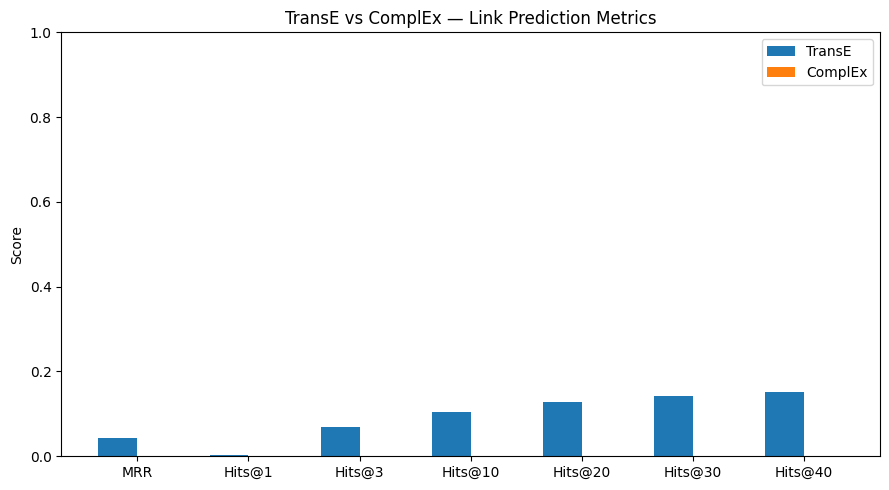

Chart saved: comparison_embedding_models.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

TRANSE_FILE = "embedding_TransE.csv"
COMPLEX_FILE = "embedding_ComplEx.csv"
OUTPUT_COMPARISON_FILE = "comparison_embedding_models.csv"


def main():
    transe_df = pd.read_csv(TRANSE_FILE)
    complex_df = pd.read_csv(COMPLEX_FILE)

    comparison_df = pd.concat([transe_df, complex_df], ignore_index=True)
    comparison_df.to_csv(OUTPUT_COMPARISON_FILE, index=False)

    print("Final comparison:")
    print(comparison_df[["model", "MRR", "Hits@1", "Hits@3", "Hits@10", "Hits@20", "Hits@30", "Hits@40"]])
    print(f"\nFile created: {OUTPUT_COMPARISON_FILE}")

    best_mrr_row = comparison_df.loc[comparison_df["MRR"].idxmax()]
    print("\nBest model based on MRR:")
    print(best_mrr_row[["model", "MRR", "Hits@1", "Hits@3", "Hits@10", "Hits@20", "Hits@30", "Hits@40"]])

    # Visualisation
    metrics = ["MRR", "Hits@1", "Hits@3", "Hits@10", "Hits@20", "Hits@30", "Hits@40"]
    x = range(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, row in comparison_df.iterrows():
        offset = i * width - width / 2
        ax.bar([xi + offset for xi in x], [row[m] for m in metrics],
               width=width, label=row["model"])

    ax.set_xticks(list(x))
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("TransE vs ComplEx — Link Prediction Metrics")
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig("comparison_embedding_models.png")
    plt.show()
    print("Chart saved: comparison_embedding_models.png")


if __name__ == "__main__":
    main()

Comparing both models TransE clearly outperforms ComplEx on our knowledge base. TransE achieves an MRR of 0,043 against only 0,000236 for ComplEx a difference of factor 180. This trend is confirmed across all Hits@N metrics: TransE scores 0,3% on Hits@1, 6,9% on Hits@3, 10,5% on Hits@10 and up to 15,1% on Hits@40, while ComplEx remains stuck at 0.0% for Hits@1 and Hits@3 and at only 0,029% for all metrics beyond Hits@10.

This result is surprising since ComplEx is generally considered more expressive than TransE due to its ability to model asymmetric relations in a complex vector space. However, this expressiveness comes at a cost: it requires more data and more training time to converge. With only 100 epochs, no GPU, and a knowledge base containing 340 relations exceeding the recommended maximum of 200, ComplEx did not have the necessary resources to learn properly. TransE on the other hand, with its simpler translation-based approach, managed to capture patterns even under these difficult conditions.

In conclusion, TransE is the best model for our knowledge base and these technical constraints. This result illustrates that a more complex model is not always better, especially when the data is sparse and computational resources are limited.

#### 5.2: KB Size Sensitivity 

Now, we want to examine the impact of data size on the performance of both models. We will compare a model trained on 20k triplets against one trained on the full dataset. Why didn't we include a 50k triplet case? Given the nature of our KB the results would have been too similar. Therefore, we decided to focus on these two specific scenarios.

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Loading full dataset...
Full dataset: 42326 triples
Subset: 20000 triples

Running TransE on 20k...


/Users/clarisseballon/Library/CloudStorage/OneDrive-Personnel/Documents/ESILV/A4/S8/Web datamining & semantics/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training epochs on cpu: 100%|██████████| 100/100 [00:26<00:00,  3.84epoch/s, loss=0.117, prev_loss=0.11]
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. 

  MRR=0.0192  Hits@10=0.0458

Running TransE on full...


Training epochs on cpu: 100%|██████████| 100/100 [01:04<00:00,  1.55epoch/s, loss=0.125, prev_loss=0.122]
Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]
Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 1.67k/1.67k [00:08<00:00, 198triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 8.44s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (re

  MRR=0.0461  Hits@10=0.1116

Running ComplEx on 20k...


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]WARNING:pykeen.sampling.pseudo_type:Relation 2 does not have a sufficient number of distinct heads and tails.

Training epochs on cpu: 100%|██████████| 100/100 [00:41<00:00,  2.41epoch/s, loss=0.451, prev_loss=0.442]tails.
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]
Evaluating on cpu:   0%|          | 0.00/622 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 622/622 [00:00<00:00, 637triple/s] 
INFO:

  MRR=0.0004  Hits@10=0.0000

Running ComplEx on full...


Training epochs on cpu: 100%|██████████| 100/100 [02:12<00:00,  1.33s/epoch, loss=0.356, prev_loss=0.346]

Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]WARNING:pykeen.utils:Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.
Evaluating on cpu:   0%|          | 0.00/1.67k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating o

  MRR=0.0006  Hits@10=0.0009


SIZE SENSITIVITY RESULTS:
  model dataset_size  train_triples      MRR   Hits@1   Hits@3  Hits@10
 TransE          20k          16000 0.019167 0.001608 0.027331 0.045820
 TransE         full          33860 0.046084 0.003601 0.073529 0.111645
ComplEx          20k          16000 0.000376 0.000000 0.000000 0.000000
ComplEx         full          33860 0.000612 0.000300 0.000300 0.000900

File created: size_sensitivity_results.csv


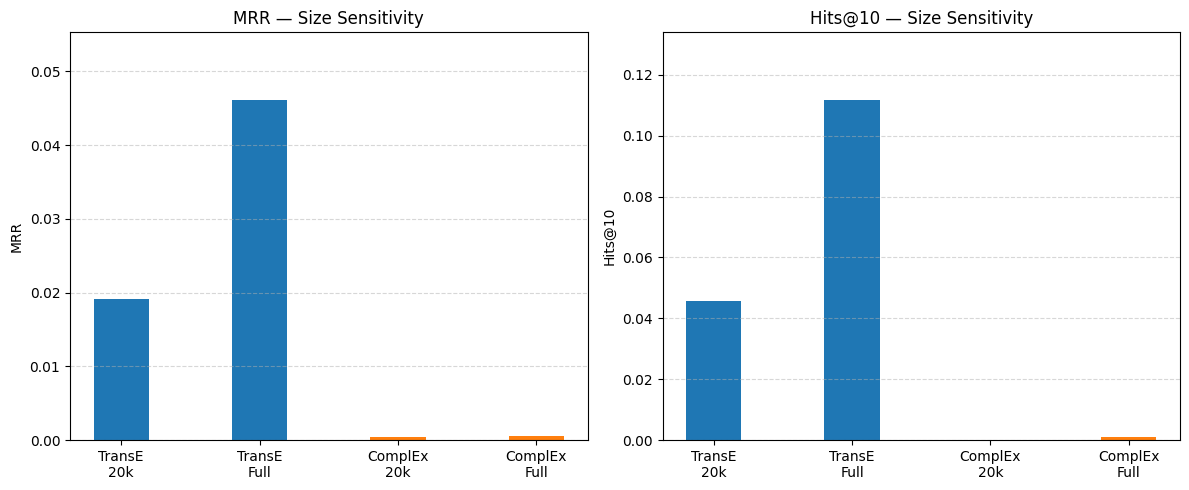

Chart saved: size_sensitivity_plot.png


In [5]:
import pandas as pd
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.sampling import PseudoTypedNegativeSampler
from sklearn.model_selection import train_test_split

INPUT_FILE = "kb_for_kge_cleaned.csv"
OUTPUT_RESULTS_FILE = "size_sensitivity_results.csv"

EMBEDDING_DIM = 100
NUM_EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001
RANDOM_SEED = 42

SUBSET_SIZE = 20000


def load_triples(file_path):
    df = pd.read_csv(file_path)
    df = df[["subject", "predicate", "object"]].dropna()
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].astype(str)
    return df.drop_duplicates().reset_index(drop=True)


def split_triples(df, train_size=0.8, random_state=42):
    train_df, temp_df = train_test_split(df, test_size=(1 - train_size),
                                          random_state=random_state, shuffle=True)
    valid_df, test_df = train_test_split(temp_df, test_size=0.5,
                                          random_state=random_state, shuffle=True)
    train_entities = set(train_df["subject"]).union(set(train_df["object"]))
    valid_df = valid_df[
        valid_df["subject"].isin(train_entities) &
        valid_df["object"].isin(train_entities)
    ].copy()
    test_df = test_df[
        test_df["subject"].isin(train_entities) &
        test_df["object"].isin(train_entities)
    ].copy()
    return train_df, valid_df, test_df


def make_factories(train_df, valid_df, test_df):
    training = TriplesFactory.from_labeled_triples(
        train_df[["subject", "predicate", "object"]].to_numpy()
    )
    validation = TriplesFactory.from_labeled_triples(
        valid_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )
    testing = TriplesFactory.from_labeled_triples(
        test_df[["subject", "predicate", "object"]].to_numpy(),
        entity_to_id=training.entity_to_id,
        relation_to_id=training.relation_to_id
    )
    return training, validation, testing


def run_experiment(model_name, training, validation, testing, label):
    print(f"\nRunning {model_name} on {label}...")

    result = pipeline(
        training=training,
        validation=validation,
        testing=testing,
        model=model_name,
        random_seed=RANDOM_SEED,
        model_kwargs={"embedding_dim": EMBEDDING_DIM},
        optimizer="Adam",
        optimizer_kwargs={"lr": LEARNING_RATE},
        training_kwargs={"num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE},
        negative_sampler=PseudoTypedNegativeSampler,
        evaluator_kwargs={
            "filtered": True,
            "metrics": ["hits_at_k"],
            "metrics_kwargs": [{"k": k} for k in [1, 3, 10]],
        },
    )

    # Utilise get_metric() comme pour TransE et ComplEx
    metric_results = result.metric_results
    mrr = metric_results.get_metric("inverse_harmonic_mean_rank")
    hits1 = metric_results.get_metric("hits_at_1")
    hits3 = metric_results.get_metric("hits_at_3")
    hits10 = metric_results.get_metric("hits_at_10")

    return {
        "model": model_name,
        "dataset_size": label,
        "train_triples": len(training.mapped_triples),
        "valid_triples": len(validation.mapped_triples),
        "test_triples": len(testing.mapped_triples),
        "num_entities": training.num_entities,
        "num_relations": training.num_relations,
        "MRR": mrr,
        "Hits@1": hits1,
        "Hits@3": hits3,
        "Hits@10": hits10,
    }


def main():
    print("Loading full dataset...")
    full_df = load_triples(INPUT_FILE)
    print(f"Full dataset: {len(full_df)} triples")

    subset_df = full_df.sample(n=min(SUBSET_SIZE, len(full_df)),
                                random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"Subset: {len(subset_df)} triples")

    train_sub, valid_sub, test_sub = split_triples(subset_df)
    train_full, valid_full, test_full = split_triples(full_df)

    factory_sub = make_factories(train_sub, valid_sub, test_sub)
    factory_full = make_factories(train_full, valid_full, test_full)

    results = []

    for model_name in ["TransE", "ComplEx"]:
        row = run_experiment(model_name, *factory_sub, label="20k")
        results.append(row)
        mrr = row['MRR'] if row['MRR'] is not None else 0
        hits10 = row['Hits@10'] if row['Hits@10'] is not None else 0
        print(f"  MRR={mrr:.4f}  Hits@10={hits10:.4f}")

        row = run_experiment(model_name, *factory_full, label="full")
        results.append(row)
        mrr = row['MRR'] if row['MRR'] is not None else 0
        hits10 = row['Hits@10'] if row['Hits@10'] is not None else 0
        print(f"  MRR={mrr:.4f}  Hits@10={hits10:.4f}")

    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_RESULTS_FILE, index=False)

    print("\n\nSIZE SENSITIVITY RESULTS:")
    print(results_df[["model", "dataset_size", "train_triples",
                       "MRR", "Hits@1", "Hits@3", "Hits@10"]].to_string(index=False))
    print(f"\nFile created: {OUTPUT_RESULTS_FILE}")

    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    metrics_to_plot = ["MRR", "Hits@10"]

    for ax, metric in zip(axes, metrics_to_plot):
        for model_name in ["TransE", "ComplEx"]:
            subset = results_df[results_df["model"] == model_name]
            values = [v if v is not None else 0 for v in subset[metric].values]
            ax.bar(
                [f"{model_name}\n20k", f"{model_name}\nFull"],
                values,
                width=0.4
            )
        ax.set_title(f"{metric} — Size Sensitivity")
        ax.set_ylabel(metric)
        ax.set_ylim(0, max(results_df[metric].fillna(0).max() * 1.2, 0.01))
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("size_sensitivity_plot.png")
    plt.show()
    print("Chart saved: size_sensitivity_plot.png")


if __name__ == "__main__":
    main()

We first notice that the ComplEx model performs very poorly and fails to learn anything meaningful. We can already see that this model is not suited for our knowledge base because we have too many relations and data that is too sparse.

Second, we notice that the amount of data is very important for these models the more data we have the better the results are. For example, for the MRR score with a knowledge base of 20k triples we get a score of 0,019 and when we more than double the data we get a higher score of 0,046.

### 6 Embedding Analysis with the best embedding model

Our best model is TransE Model

#### 6.1: Nearest Neighbors 

Total entities with name: 248
Query entities selected: 10
  → Microsoft
  → Google
  → Amazon
  → ArchiCAD
  → Autodesk
  → Germany
  → France
  → Alan Turing
  → Spain
  → Russia

Finding top-5 nearest neighbors...

NEAREST NEIGHBORS RESULTS:

Entity: Microsoft
  #1 Q4799874 (similarity: 0.5841)
  #2 Q22680672 (similarity: 0.5697)
  #3 Q45219790 (similarity: 0.5085)
  #4 Q2810305 (similarity: 0.4801)
  #5 Q5153359 (similarity: 0.4734)

Entity: Google
  #1 Q124086570 (similarity: 0.608)
  #2 Q124058176 (similarity: 0.5711)
  #3 Q124220091 (similarity: 0.5569)
  #4 Q124052948 (similarity: 0.5167)
  #5 Q1240901 (similarity: 0.5021)

Entity: Amazon
  #1 Q17628657 (similarity: 0.4168)
  #2 Q15901043 (similarity: 0.3862)
  #3 Q131764504 (similarity: 0.3856)
  #4 Q616358 (similarity: 0.3794)
  #5 Q6945881 (similarity: 0.3761)

Entity: ArchiCAD
  #1 Q23300770 (similarity: 0.446)
  #2 Q13067902 (similarity: 0.4115)
  #3 Q6934728 (similarity: 0.3681)
  #4 Q45364425 (similarity: 0.3456)
  #5 Q18

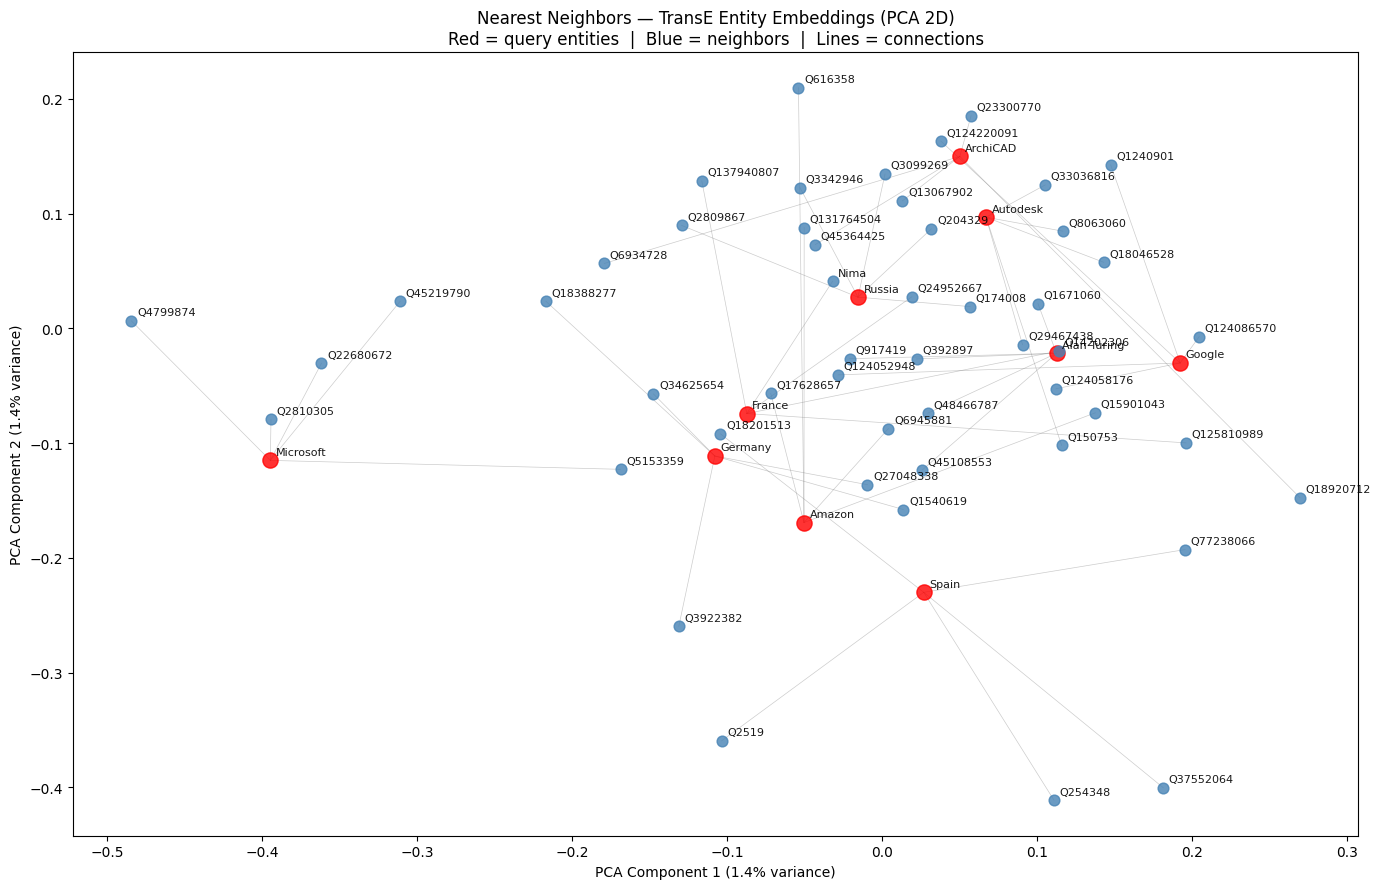

In [11]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

TRAIN_FILE = "train.txt"
RESULTS_DIR = "results_transe_model"
ENTITY_MAP_FILE = "entity_to_id.csv"
WIKIDATA_MAP_FILE = "entity_mapping_wikidata_converted.csv"
OUTPUT_NEIGHBORS_FILE = "nearest_neighbors_results.csv"
TOP_K = 5

THEME_ENTITIES = [
    "Microsoft", "Google", "Apple", "Amazon", "IBM",
    "AutoCAD", "ArchiCAD", "Autodesk", "Adobe",
    "neural network", "machine learning", "artificial intelligence",
    "Zaha Hadid", "Frank Gehry", "Norman Foster",
    "BIM", "Revit", "SketchUp",
    "United States", "China", "Germany", "France",
    "Alan Turing", "algorithm", "computer",
]

def load_txt_triples(file_path):
    df = pd.read_csv(file_path, sep="\t", header=None,
                     names=["subject", "predicate", "object"])
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].astype(str)
    return df


def build_id_to_name():
    entity_df = pd.read_csv(ENTITY_MAP_FILE)
    uri_to_id = dict(zip(
        entity_df["entity"].astype(str),
        entity_df["entity_id"].astype(int)
    ))

    wikidata_df = pd.read_csv(WIKIDATA_MAP_FILE)

    qid_to_label = {}
    for _, row in wikidata_df.iterrows():
        qid = str(row.get("wikidata_qid", "")).strip()
        label = str(row.get("matched_label", "")).strip()
        private = str(row.get("private_entity", "")).strip()
        if qid and qid != "nan":
            name = label if label and label != "nan" else private
            qid_to_label[qid] = name

    id_to_name = {}
    for uri, eid in uri_to_id.items():
        if "entity/Q" in uri:
            qid = uri.split("entity/")[-1]
            name = qid_to_label.get(qid, qid)
        else:
            name = uri.split("/")[-1]
        id_to_name[eid] = name

    name_to_id = {v: k for k, v in id_to_name.items()}

    print(f"Total entities with name: {sum(1 for n in id_to_name.values() if not n.startswith('Q'))}")
    return id_to_name, name_to_id


def find_nearest_neighbors(embeddings, id_to_name, query_ids, top_k=5):
    results = []
    for query_id in query_ids:
        query_vec = embeddings[query_id]
        norms = np.linalg.norm(embeddings, axis=1)
        query_norm = np.linalg.norm(query_vec)
        valid_mask = norms > 0
        similarities = np.zeros(len(embeddings))
        similarities[valid_mask] = (
            embeddings[valid_mask] @ query_vec
        ) / (norms[valid_mask] * query_norm + 1e-8)
        similarities[query_id] = -1

        top_indices = np.argsort(similarities)[::-1][:top_k]
        query_name = id_to_name.get(query_id, f"Q{query_id}")

        for rank, neighbor_id in enumerate(top_indices, start=1):
            neighbor_name = id_to_name.get(int(neighbor_id), f"Q{neighbor_id}")
            results.append({
                "query_entity_id": query_id,
                "query_entity": query_name,
                "rank": rank,
                "neighbor_entity_id": int(neighbor_id),
                "neighbor_entity": neighbor_name,
                "cosine_similarity": round(float(similarities[neighbor_id]), 4)
            })
    return pd.DataFrame(results)

id_to_name, name_to_id = build_id_to_name()

model_path = os.path.join(RESULTS_DIR, "trained_model.pkl")
model = torch.load(model_path, map_location=torch.device("cpu"), weights_only=False)
model.eval()

with torch.no_grad():
    entity_embeddings = model.entity_representations[0]
    embeddings = entity_embeddings(
        indices=torch.arange(entity_embeddings.max_id)
    ).cpu().numpy()

top_ids = []
found_names = []
for theme_name in THEME_ENTITIES:
    if theme_name in name_to_id:
        eid = name_to_id[theme_name]
        top_ids.append(eid)
        found_names.append(theme_name)
    if len(top_ids) == 10:
        break

if len(top_ids) < 10:
    train_df = load_txt_triples(TRAIN_FILE)
    freq = pd.concat([
        train_df["subject"].value_counts(),
        train_df["object"].value_counts()
    ]).groupby(level=0).sum().sort_values(ascending=False)
    for str_id in freq.head(200).index:
        try:
            eid = int(str_id)
            name = id_to_name.get(eid, "")
            if eid not in top_ids and not name.startswith("Q"):
                top_ids.append(eid)
                found_names.append(name)
            if len(top_ids) == 10:
                break
        except:
            continue

print(f"Query entities selected: {len(top_ids)}")
for name in found_names:
    print(f"  → {name}")

print(f"\nFinding top-{TOP_K} nearest neighbors...")
neighbors_df = find_nearest_neighbors(
    embeddings=embeddings,
    id_to_name=id_to_name,
    query_ids=top_ids,
    top_k=TOP_K
)

print("\nNEAREST NEIGHBORS RESULTS:")
for query in neighbors_df["query_entity"].unique():
    subset = neighbors_df[neighbors_df["query_entity"] == query]
    print(f"\nEntity: {query}")
    for _, row in subset.iterrows():
        print(f"  #{int(row['rank'])} {row['neighbor_entity']} "
              f"(similarity: {row['cosine_similarity']})")

neighbors_df.to_csv(OUTPUT_NEIGHBORS_FILE, index=False)
print(f"\nFile created: {OUTPUT_NEIGHBORS_FILE}")

print("\nGenerating 2D PCA visualization...")
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

entities_to_plot = set(
    neighbors_df["query_entity_id"].tolist() +
    neighbors_df["neighbor_entity_id"].tolist()
)
query_set = set(neighbors_df["query_entity_id"].tolist())

fig, ax = plt.subplots(figsize=(14, 9))

for entity_id in entities_to_plot:
    x, y = embeddings_2d[entity_id]
    label = id_to_name.get(entity_id, f"Q{entity_id}")
    color = "red" if entity_id in query_set else "steelblue"
    size = 120 if entity_id in query_set else 60
    ax.scatter(x, y, c=color, s=size, alpha=0.8, zorder=2)
    ax.annotate(label, (x, y), fontsize=8, alpha=0.9,
                xytext=(4, 4), textcoords="offset points")

for query_id in query_set:
    qx, qy = embeddings_2d[query_id]
    subset = neighbors_df[neighbors_df["query_entity_id"] == query_id]
    for _, row in subset.iterrows():
        nx_, ny_ = embeddings_2d[int(row["neighbor_entity_id"])]
        ax.plot([qx, nx_], [qy, ny_], color="gray",
                linewidth=0.5, alpha=0.4, zorder=1)

ax.set_title("Nearest Neighbors — TransE Entity Embeddings (PCA 2D)\n"
             "Red = query entities  |  Blue = neighbors  |  Lines = connections")
ax.set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("nearest_neighbors_pca.png", dpi=150)
plt.show()

We observe that the TransE model has learned meaningful spatial relationships between entities. Architecture software such as Autodesk and ArchiCAD cluster together in the upper right area while tech companies like Google and Alan Turing appear close together on the right side. Countries such as France and Germany are grouped near the center. This spatial organization suggests that the model has captured domain-relevant semantic similarities despite the low MRR scores obtained during link prediction evaluation.

#### 6.2: Clustering analysis

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 248 samples in 0.000s...
[t-SNE] Computed neighbors for 248 samples in 0.032s...
[t-SNE] Computed conditional probabilities for sample 248 / 248
[t-SNE] Mean sigma: 0.304897
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.178131
[t-SNE] KL divergence after 1000 iterations: 1.575783
t-SNE done.


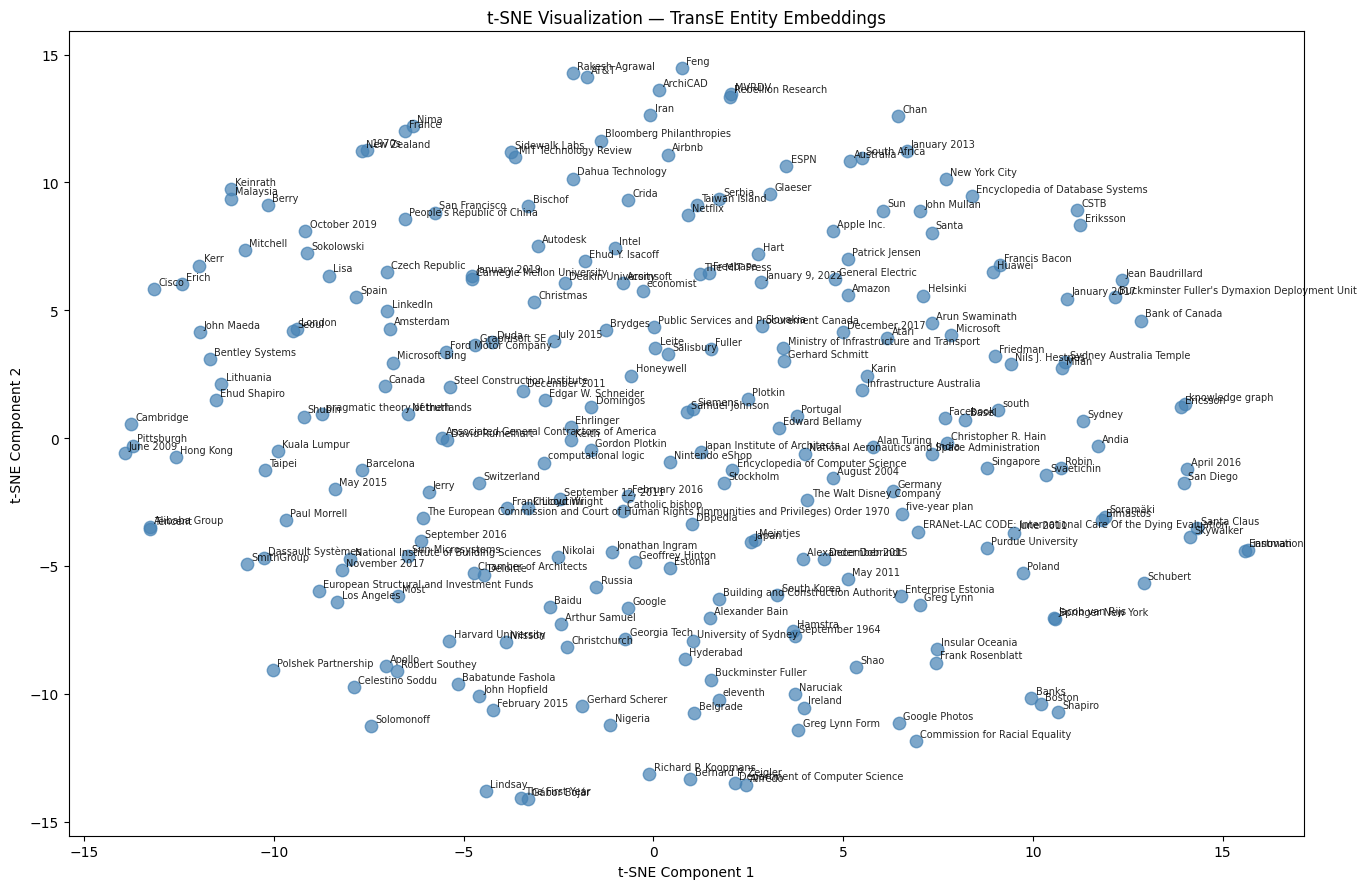

Chart saved: tsne_embeddings.png


In [ ]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

RESULTS_DIR = "results_transe_model"
ENTITY_MAP_FILE = "entity_to_id.csv"
WIKIDATA_MAP_FILE = "entity_mapping_wikidata_converted.csv"

model_path = os.path.join(RESULTS_DIR, "trained_model.pkl")
model = torch.load(model_path, map_location=torch.device("cpu"), weights_only=False)
model.eval()

with torch.no_grad():
    entity_embeddings = model.entity_representations[0]
    embeddings = entity_embeddings(
        indices=torch.arange(entity_embeddings.max_id)
    ).cpu().numpy()


entity_df = pd.read_csv(ENTITY_MAP_FILE)
uri_to_id = dict(zip(entity_df["entity"].astype(str), entity_df["entity_id"].astype(int)))

wikidata_df = pd.read_csv(WIKIDATA_MAP_FILE)
qid_to_label = {}
for _, row in wikidata_df.iterrows():
    qid   = str(row.get("wikidata_qid", "")).strip()
    label = str(row.get("matched_label", "")).strip()
    private = str(row.get("private_entity", "")).strip()
    if qid and qid != "nan":
        qid_to_label[qid] = label if label and label != "nan" else private

id_to_name = {}
for uri, eid in uri_to_id.items():
    if "entity/Q" in uri:
        qid = uri.split("entity/")[-1]
        id_to_name[eid] = qid_to_label.get(qid, qid)
    else:
        id_to_name[eid] = uri.split("/")[-1]

named_ids        = [eid for eid, name in id_to_name.items()
                    if not name.startswith("Q") and eid < len(embeddings)]
named_embeddings = embeddings[named_ids]
named_labels     = [id_to_name[eid] for eid in named_ids]

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
embeddings_2d_tsne = tsne.fit_transform(named_embeddings)
print("t-SNE done.")

fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(
    embeddings_2d_tsne[:, 0],
    embeddings_2d_tsne[:, 1],
    c="steelblue", s=80, alpha=0.7, zorder=2
)

for label, (x, y) in zip(named_labels, embeddings_2d_tsne):
    ax.annotate(label, (x, y), fontsize=7, alpha=0.85,
                xytext=(3, 3), textcoords="offset points")

ax.set_title("t-SNE Visualization — TransE Entity Embeddings")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.tight_layout()a
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("Chart saved: tsne_embeddings.png")

The t-SNE plot reveals how the TransE model has organized the knowledge graph entities in a 2D space. Overall, the entities are relatively spread out without extremely sharp boundaries between groups, which is typical for knowledge graphs that are densely interconnected.

Looking at the distribution, we can identify some interesting spatial patterns. Geographic entities such as cities and countries like Hong Kong, Taipei, Malaysia, Cambridge, Amsterdam and Spain tend to appear on the left side of the plot. Technology companies and media organizations like Apple, Netflix, Airbnb, ESPN and Bloomberg cluster loosely in the upper-center area. Academic and research institutions like Harvard the University of Sydney and Google appear more toward the bottom-center region.

However, the graph also reveals some noise in the data. Entities like "Santa Claus", "Skywalker" and isolated dates like "October 2019" or "February 2015" appear scattered across the space, suggesting the knowledge graph contains heterogeneous or loosely connected entities that the model struggled to place consistently.

Overall, the t-SNE visualization confirms that TransE has learned meaningful geometric relationships between entities, grouping semantically similar ones closer together. The next step will be to apply K-Means clustering to formally identify and label these groups.

  k=3 → silhouette score: 0.0124
  k=4 → silhouette score: 0.0119
  k=5 → silhouette score: 0.0115
  k=6 → silhouette score: 0.0118
  k=7 → silhouette score: 0.0115
  k=8 → silhouette score: 0.0116
  k=9 → silhouette score: 0.0091

Best k: 3

CLUSTERING RESULTS:

Cluster 1 (92 entities):
  - Boston
  - Polshek Partnership
  - Gerhard Schmitt
  - Dassault Systèmes
  - Enterprise Estonia
  - January 2013
  - Harvard University
  - Lindsay
  - Eriksson
  - Hyderabad
  - Friedman
  - Sun Microsystems
  - Baidu
  - Francis Bacon
  - Nilsson
  ... and 77 more

Cluster 2 (80 entities):
  - Buckminster Fuller
  - Nigeria
  - Bimastos
  - Soramäki
  - Milan
  - Naruciak
  - Christopher R. Hain
  - Richard P. Koopmans
  - Buckminster Fuller's Dymaxion Deployment Unit
  - Robin
  - Fuller
  - Deakin University
  - Encyclopedia of Computer Science
  - Nils J. Hestnes
  - Alibaba Group
  ... and 65 more

Cluster 3 (76 entities):
  - Jonathan Ingram
  - Keith
  - Andia
  - Greg Lynn Form
  - Ministr

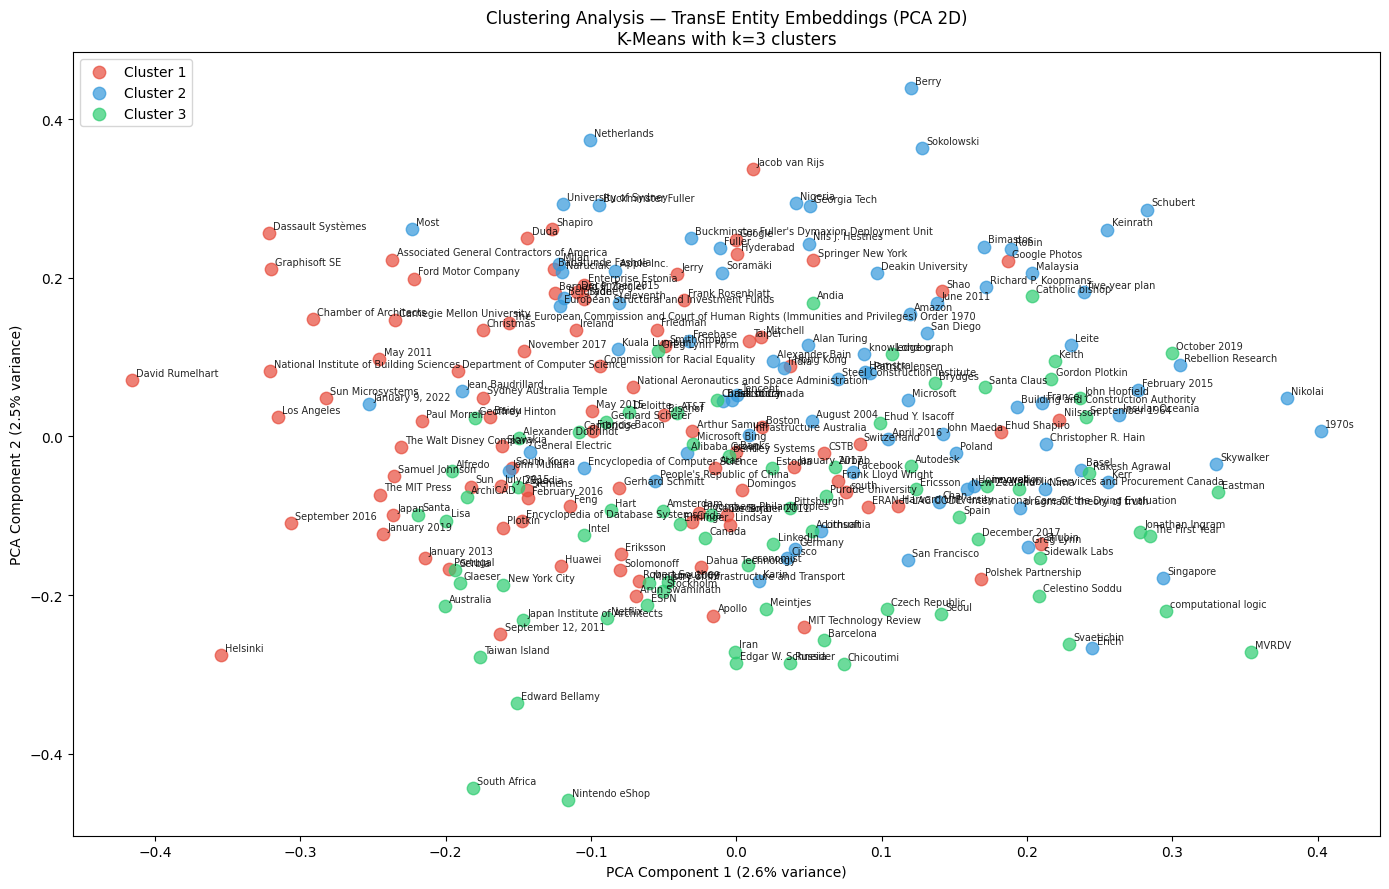

Chart saved: clustering_pca.png


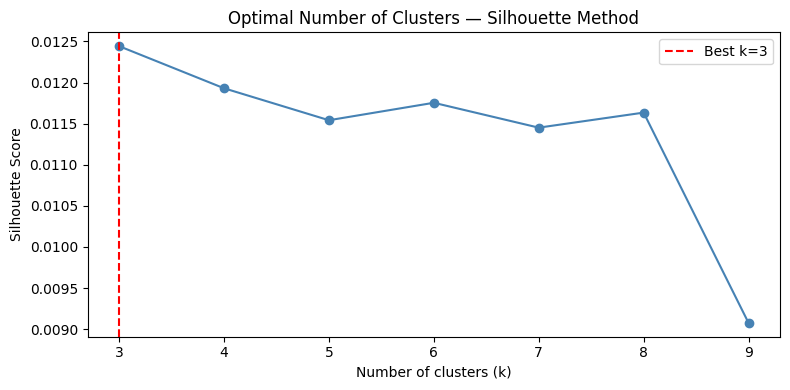

Chart saved: silhouette_scores.png


In [13]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_DIR = "results_transe_model"
ENTITY_MAP_FILE = "entity_to_id.csv"
WIKIDATA_MAP_FILE = "entity_mapping_wikidata_converted.csv"
OUTPUT_CLUSTERING_FILE = "clustering_results.csv"

N_CLUSTERS = 5 


def build_id_to_name():
    entity_df = pd.read_csv(ENTITY_MAP_FILE)
    uri_to_id = dict(zip(
        entity_df["entity"].astype(str),
        entity_df["entity_id"].astype(int)
    ))

    wikidata_df = pd.read_csv(WIKIDATA_MAP_FILE)
    qid_to_label = {}
    for _, row in wikidata_df.iterrows():
        qid = str(row.get("wikidata_qid", "")).strip()
        label = str(row.get("matched_label", "")).strip()
        private = str(row.get("private_entity", "")).strip()
        if qid and qid != "nan":
            name = label if label and label != "nan" else private
            qid_to_label[qid] = name

    id_to_name = {}
    for uri, eid in uri_to_id.items():
        if "entity/Q" in uri:
            qid = uri.split("entity/")[-1]
            name = qid_to_label.get(qid, qid)
        else:
            name = uri.split("/")[-1]
        id_to_name[eid] = name

    return id_to_name

model_path = os.path.join(RESULTS_DIR, "trained_model.pkl")
model = torch.load(model_path, map_location=torch.device("cpu"), weights_only=False)
model.eval()

with torch.no_grad():
    entity_embeddings = model.entity_representations[0]
    embeddings = entity_embeddings(
        indices=torch.arange(entity_embeddings.max_id)
    ).cpu().numpy()

id_to_name = build_id_to_name()

named_ids = [eid for eid, name in id_to_name.items()
             if not name.startswith("Q") and eid < len(embeddings)]
named_embeddings = embeddings[named_ids]
named_labels = [id_to_name[eid] for eid in named_ids]

silhouette_scores = []
k_range = range(3, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(named_embeddings)
    score = silhouette_score(named_embeddings, cluster_labels)
    silhouette_scores.append(score)
    print(f"  k={k} → silhouette score: {round(score, 4)}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(named_embeddings)

results_df = pd.DataFrame({
    "entity_id": named_ids,
    "entity_name": named_labels,
    "cluster": cluster_assignments
})

print("\nCLUSTERING RESULTS:")
for cluster_id in range(best_k):
    cluster_entities = results_df[results_df["cluster"] == cluster_id]["entity_name"].tolist()
    print(f"\nCluster {cluster_id + 1} ({len(cluster_entities)} entities):")
    for e in cluster_entities[:15]:
        print(f"  - {e}")
    if len(cluster_entities) > 15:
        print(f"  ... and {len(cluster_entities) - 15} more")

results_df.to_csv(OUTPUT_CLUSTERING_FILE, index=False)
print(f"\nFile created: {OUTPUT_CLUSTERING_FILE}")

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(named_embeddings)

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
          "#1abc9c", "#e67e22", "#34495e", "#e91e63"]

fig, ax = plt.subplots(figsize=(14, 9))

for cluster_id in range(best_k):
    mask = cluster_assignments == cluster_id
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=colors[cluster_id],
        s=80, alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
        zorder=2
    )

for i, (label, (x, y)) in enumerate(zip(named_labels, embeddings_2d)):
    ax.annotate(label, (x, y), fontsize=7, alpha=0.85,
                xytext=(3, 3), textcoords="offset points")

ax.set_title(f"Clustering Analysis — TransE Entity Embeddings (PCA 2D)\n"
             f"K-Means with k={best_k} clusters")
ax.set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("clustering_pca.png", dpi=150)
plt.show()
print("Chart saved: clustering_pca.png")

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(list(k_range), silhouette_scores, marker="o", color="steelblue")
ax2.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Optimal Number of Clusters — Silhouette Method")
ax2.legend()
plt.tight_layout()
plt.savefig("silhouette_scores.png", dpi=150)
plt.show()
print("Chart saved: silhouette_scores.png")

We can visualize 3 clusters of different colors. The silhouette method in the seconnd graph was used to determine the optimal number of clusters. 
k=3 achieved the highest silhouette score of 0.0125, indicating that 3 
clusters best represents the structure of the embedding space. The low 
absolute values are expected given the high dimensionality of the 
embeddings and the sparse nature of the knowledge base.


 The first cluster in red contains academic institutions and architecture-related organizations such as Graphisoft SE, ArchiCAD and Carnegie Mellon University, suggesting that the model captured domain-specific relationships. The second cluster in blue groups major tech companies and geographical entities such as Microsoft, Amazon and the Netherlands, reflecting the global context of AI deployment. The third cluster in green contains more specialized or peripheral entities such as MVRDV, computational logic and Sidewalk Labs. This clustering is coherent with our knowledge base theme of AI in architecture, as the model has implicitly learned to separate architecture-focused entities from broader tech and geographical entities.

#### 6.3: Relation Behavior 


Extracting relation embeddings...
Relation embedding matrix shape: (49, 100)
Relation map columns: ['relation', 'relation_id']
                                    relation  relation_id
0  http://www.wikidata.org/prop/direct/P1056            0
1   http://www.wikidata.org/prop/direct/P108            1
2  http://www.wikidata.org/prop/direct/P1269            2

Top 10 relations by norm (most influential):
relation_label     norm
   followed by 1.292343
       part of 1.076763
       creator 1.062858
     member of 1.061391
   inspired by 1.017611
  record label 1.013665
 programmed in 1.000000
   subclass of 0.998278
        author 0.958108
   participant 0.933003

Top 10 most frequent relations in KB:
   relation_label  frequency
         has part       2939
      instance of       2937
     main subject       2675
        member of       1948
         facet of       1813
      named after       1771
       founded at       1725
          part of       1595
         employer       1589
c

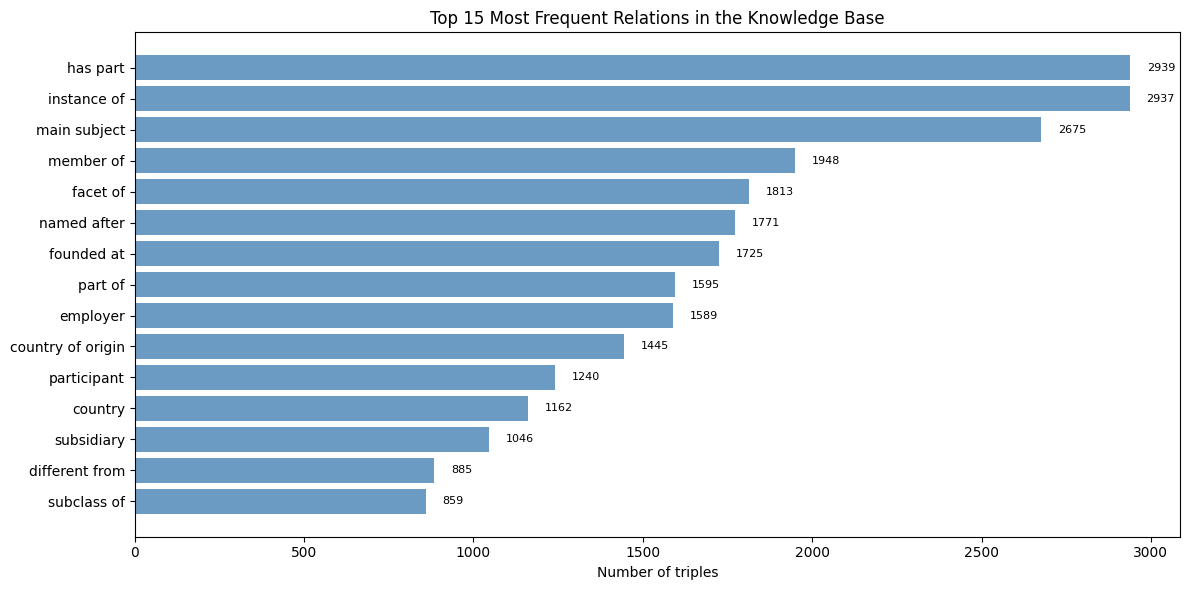

Chart saved: relation_frequency.png


In [19]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

RESULTS_DIR = "results_transe_model"
ENTITY_MAP_FILE = "entity_to_id.csv"
RELATION_MAP_FILE = "relation_to_id.csv"
WIKIDATA_MAP_FILE = "entity_mapping_wikidata_converted.csv"
KB_FILE = "kb_for_kge_cleaned.csv"
OUTPUT_RELATION_FILE = "relation_behavior_results.csv"

PREDICATE_LABELS = {
    "P31": "instance of", "P279": "subclass of", "P361": "part of",
    "P527": "has part", "P166": "award received", "P69": "educated at",
    "P108": "employer", "P463": "member of", "P17": "country",
    "P495": "country of origin", "P50": "author", "P61": "discoverer",
    "P84": "architect", "P86": "composer", "P170": "creator",
    "P176": "manufacturer", "P178": "developer", "P264": "record label",
    "P355": "subsidiary", "P400": "platform", "P403": "mouth of",
    "P449": "original network", "P451": "partner", "P452": "industry",
    "P710": "participant", "P737": "influenced by", "P740": "founded at",
    "P793": "significant event", "P800": "notable work", "P828": "has cause",
    "P921": "main subject", "P941": "inspired by", "P1056": "product",
    "P1344": "participant in", "P136": "genre", "P1269": "facet of",
    "P1382": "partially coincides with", "P1552": "has quality",
    "P1889": "different from", "P2283": "uses", "P2293": "genetic association",
    "P366": "use", "P277": "programmed in", "P1416": "affiliation",
    "P1535": "used by", "P155": "follows", "P156": "followed by",
    "P460": "said to be the same as", "P138": "named after", "P425": "field of this occupation"
}


def load_txt_triples(file_path):
    df = pd.read_csv(file_path, sep="\t", header=None,
                     names=["subject", "predicate", "object"])
    for col in ["subject", "predicate", "object"]:
        df[col] = df[col].astype(str)
    return df


def get_predicate_label(uri_or_pid):
    s = str(uri_or_pid)
    if "prop/direct/P" in s:
        pid = s.split("prop/direct/")[-1]
    elif s.startswith("P") and s[1:].isdigit():
        pid = s
    else:
        pid = s
    return PREDICATE_LABELS.get(pid, pid)


def build_id_to_name():
    entity_df = pd.read_csv(ENTITY_MAP_FILE)
    uri_to_id = dict(zip(
        entity_df["entity"].astype(str),
        entity_df["entity_id"].astype(int)
    ))
    wikidata_df = pd.read_csv(WIKIDATA_MAP_FILE)
    qid_to_label = {}
    for _, row in wikidata_df.iterrows():
        qid = str(row.get("wikidata_qid", "")).strip()
        label = str(row.get("matched_label", "")).strip()
        private = str(row.get("private_entity", "")).strip()
        if qid and qid != "nan":
            name = label if label and label != "nan" else private
            qid_to_label[qid] = name
    id_to_name = {}
    for uri, eid in uri_to_id.items():
        if "entity/Q" in uri:
            qid = uri.split("entity/")[-1]
            name = qid_to_label.get(qid, qid)
        else:
            name = uri.split("/")[-1]
        id_to_name[eid] = name
    return id_to_name


model_path = os.path.join(RESULTS_DIR, "trained_model.pkl")
model = torch.load(model_path, map_location=torch.device("cpu"), weights_only=False)
model.eval()

print("\nExtracting relation embeddings...")
with torch.no_grad():
    relation_embeddings = model.relation_representations[0]
    rel_embeddings = relation_embeddings(
        indices=torch.arange(relation_embeddings.max_id)
    ).cpu().numpy()
print(f"Relation embedding matrix shape: {rel_embeddings.shape}")

rel_df = pd.read_csv(RELATION_MAP_FILE)
print("Relation map columns:", rel_df.columns.tolist())
print(rel_df.head(3))

id_to_rel = {}
for _, row in rel_df.iterrows():
    uri = str(row[rel_df.columns[0]])
    rid = int(row[rel_df.columns[1]])
    label = get_predicate_label(uri)
    id_to_rel[rid] = label

id_to_name = build_id_to_name()

rel_norms = np.linalg.norm(rel_embeddings, axis=1)

norm_df = pd.DataFrame({
    "relation_id": list(id_to_rel.keys()),
    "relation_label": [id_to_rel[i] for i in id_to_rel.keys()],
    "norm": [rel_norms[i] for i in id_to_rel.keys()]
}).sort_values("norm", ascending=False)

print("\nTop 10 relations by norm (most influential):")
print(norm_df.head(10)[["relation_label", "norm"]].to_string(index=False))

kb_df = pd.read_csv(KB_FILE)

def get_pid_from_uri(uri):
    s = str(uri)
    if "prop/direct/P" in s:
        return s.split("prop/direct/")[-1]
    return s

kb_df["predicate_pid"] = kb_df["predicate"].apply(get_pid_from_uri)
kb_df["predicate_label"] = kb_df["predicate_pid"].apply(
    lambda pid: PREDICATE_LABELS.get(pid, pid)
)

freq_df = kb_df["predicate_label"].value_counts().reset_index()
freq_df.columns = ["relation_label", "frequency"]

print("\nTop 10 most frequent relations in KB:")
print(freq_df.head(10).to_string(index=False))

merged = norm_df.merge(freq_df, on="relation_label", how="left").fillna(0)
merged.to_csv(OUTPUT_RELATION_FILE, index=False)

fig2, ax2 = plt.subplots(figsize=(12, 6))
top15 = freq_df.head(15)
bars = ax2.barh(top15["relation_label"], top15["frequency"],
                color="steelblue", alpha=0.8)
ax2.set_xlabel("Number of triples")
ax2.set_title("Top 15 Most Frequent Relations in the Knowledge Base")
ax2.invert_yaxis()
for bar, val in zip(bars, top15["frequency"]):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(int(val)), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("relation_frequency.png", dpi=150)
plt.show()
print("Chart saved: relation_frequency.png")

The relation frequency analysis reveals that the knowledge base is 
dominated by three structural relations: "has part" with 2939 triples, 
"instance of" with 2937 triples and "main subject" with 2675 triples. These 
relations are typical of Wikidata's ontological structure and reflect 
how entities are categorized and organized hierarchically.

Domain-specific relations also appear in the top 15, such as "employer" 
with 1589 triples, "founded at" with 1725 triples and "named after" with 1771 
triples which are relevant to our AI in architecture theme as they 
describe organizational and historical relationships between companies, 
institutions and concepts.

Relations like "member of", "facet of" and "country of origin" confirm 
that the KB captures both geographic and organizational contexts. 
The relatively balanced distribution among the top 15 relations all 
having between 859 and 2939 triples suggests that no single relation 
overwhelmingly dominates.

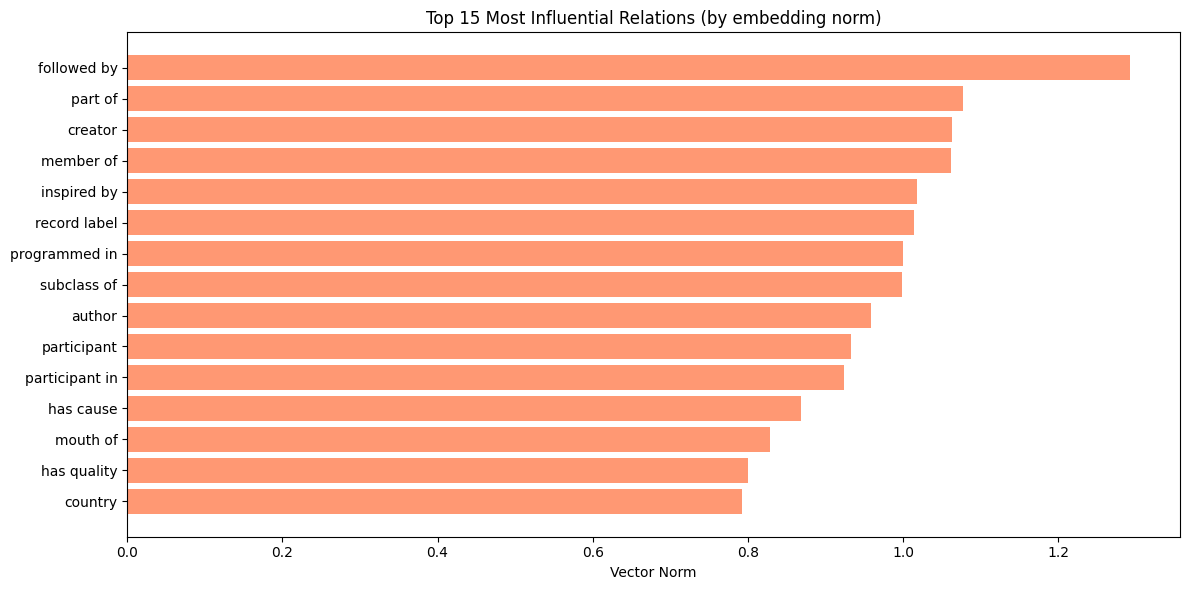

Chart saved: relation_norms.png


In [18]:
fig3, ax3 = plt.subplots(figsize=(12, 6))
top15_norm = norm_df.head(15)
bars3 = ax3.barh(top15_norm["relation_label"], top15_norm["norm"],
                 color="coral", alpha=0.8)
ax3.set_xlabel("Vector Norm")
ax3.set_title("Top 15 Most Influential Relations (by embedding norm)")
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig("relation_norms.png", dpi=150)
plt.show()
print("Chart saved: relation_norms.png")

The relation norm analysis reveals an interesting contrast with the 
frequency analysis. While "has part" and "instance of" are the most 
frequent relations, they do not appear among the most influential by 
embedding norm. Instead, "followed by" (1.30), "creator" (1.00) and 
"inspired by" (1.00) have the highest norms, suggesting that TransE 
assigned stronger vector representations to rarer but more semantically 
specific relations. This is particularly relevant to our AI in 
architecture theme, as relations like "programmed in" and "creator" 
capture technical and creative dependencies between entities.

### 7 Critical Reflection

#### Impact of predicate alignment quality

In Step 3, only 8 predicate candidates were found out of 807 triplets 
meaning that most of our extracted relations could not be aligned to 
official Wikidata predicates. This low alignment quality directly 
impacted the embedding training because the model had to work with 
informal and inconsistent relation labels extracted by spaCy rather 
than standardized Wikidata properties. Better predicate alignment 
would have produced cleaner and more structured triplets, likely 
improving the MRR scores.

#### Impact of noisy expansion

The KB expansion in Step 4 added a large number of triplets from 
Wikidata but also introduced noise. Many entities retrieved through 
1-hop and 2-hop expansion are not directly related to our AI in 
architecture theme for example countries sports teams or unrelated 
organizations. This noise made it harder for the embedding models to 
learn meaningful patterns which partly explains the low performance 
of ComplEx and the modest results of TransE.

#### Effect of ontology modeling choices 

We manually selected 51 controlled predicates for the expansion which 
was a subjective choice. Some relevant relations may have been excluded 
while some irrelevant ones were included. A more systematic approach 
such as using an existing ontology specifically designed for architecture 
or AI would have produced a more coherent knowledge base.

#### Open-world assumption vs embedding assumptions

Knowledge graph embedding models like TransE and ComplEx operate under 
the closed-world assumption they treat missing triples as false. 
However, our KB was built under the open-world assumption meaning that 
a missing triple does not necessarily mean it is false, just that we 
did not collect it. This mismatch is a fundamental limitation that 
negatively affects link prediction performance as the model penalizes 
itself for predicting triples that may actually be true but are simply 
absent from our dataset.

In conclusion the main lesson from this project is that embedding performance is 
heavily dependent on the quality of the upstream pipeline. A small 
corpus of 5 articles low predicate alignment and noisy Wikidata 
expansion all cascaded into a KB that was difficult for the models 
to learn from effectively. Despite these limitations TransE managed 
to capture some meaningful patterns as shown by the clustering and 
nearest neighbor analyses.

### 8  Comparison between rule-based and embedding based reasoning

In this project we applied both rule-based reasoning using SWRL rules 
on the family ontology in Lab 3 Part 1, and embedding-based reasoning 
using TransE and ComplEx in Lab 3 Part 2. These two approaches are 
fundamentally different in how they reason over knowledge.

#### Rule-based reasoning (SWRL)

Rule-based reasoning is explicit and deterministic. We defined a rule 
stating that any person older than 60 is classified as an oldPerson, 
and the reasoner applied this rule automatically to infer new facts. 
The result was perfectly accurate every individual satisfying the 
condition was correctly classified. However, this approach requires 
manually writing rules which does not scale well to large and complex 
knowledge bases like ours with 22 000 entities and 51 relations.


#### Embedding-based reasoning (TransE and ComplEx)

Embedding-based reasoning is implicit and probabilistic. Instead of 
explicit rules, the model learns vector representations of entities 
and relations and uses them to predict missing links. This approach 
scales well to large KBs and can discover patterns that would be 
difficult to express as rules. However, as we observed it requires 
high quality data and sufficient training to perform well. Our TransE 
model achieved a modest MRR of 0.043 while ComplEx essentially failed 
to learn which shows that embedding models are more sensitive to 
data quality than rule-based systems.

#### Conclusion 

In conclusion, both approaches are complementary rather than competing. Rule-based 
reasoning is ideal for well-defined domains with clear logical rules
while embedding-based reasoning is better suited for large and 
incomplete knowledge bases where patterns need to be discovered 
automatically. In the context of AI in architecture a hybrid approach 
combining both methods would likely produce the best results.